We are building a cardiovascular decision-support platform with two complementary models:

a preventive model for estimating 10-year CHD risk
a triage model for assessing likelihood of current heart disease in a symptom-oriented setting

In [1]:
import os
import json
import joblib
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.base import clone
import matplotlib.pyplot as plt
from scipy.stats import spearmanr
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.calibration import CalibratedClassifierCV, calibration_curve, CalibrationDisplay
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, StackingClassifier
from sklearn.model_selection import train_test_split, cross_validate, StratifiedKFold, RepeatedStratifiedKFold
from sklearn.metrics import (average_precision_score, classification_report, roc_auc_score, confusion_matrix, balanced_accuracy_score,
precision_score, recall_score, ConfusionMatrixDisplay, brier_score_loss, PrecisionRecallDisplay, f1_score)

# Framingham Heart Study: 10-Year CHD Risk Prediction

In this notebook, we use the Framingham dataset to predict whether a patient will develop coronary heart disease (CHD) within the next 10 years. This is a supervised binary classification task, where the target variable "TenYearCHD" indicates the presence or absence of future CHD.

In [2]:
# load dataset
df = pd.read_csv("framingham.csv")

# quick copy to avoid accidental overwrite
df_original = df.copy()

In [3]:
df.head()

,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,1,39,4.0,0,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0
1,0,46,2.0,0,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,0
2,1,48,1.0,1,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0,0
3,0,61,3.0,1,30.0,0.0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0,1
4,0,46,3.0,1,23.0,0.0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0,0


In [4]:
df.shape

(4240, 16)

In [5]:
df.describe()

,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
count,4240.000000,4240.000000,4135.000000,4240.000000,4211.000000,4187.000000,4240.000000,4240.000000,4240.000000,4190.000000,4240.000000,4240.000000,4221.000000,4239.000000,3852.000000,4240.000000
mean,0.429245,49.580189,1.979444,0.494104,9.005937,0.029615,0.005896,0.310613,0.025708,236.699523,132.354599,82.897759,25.800801,75.878981,81.963655,0.151887
std,0.495027,8.572942,1.019791,0.500024,11.922462,0.169544,0.076569,0.462799,0.158280,44.591284,22.033300,11.910394,4.079840,12.025348,23.954335,0.358953
min,0.000000,32.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,107.000000,83.500000,48.000000,15.540000,44.000000,40.000000,0.000000
25%,0.000000,42.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,206.000000,117.000000,75.000000,23.070000,68.000000,71.000000,0.000000
50%,0.000000,49.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,234.000000,128.000000,82.000000,25.400000,75.000000,78.000000,0.000000
75%,1.000000,56.000000,3.000000,1.000000,20.000000,0.000000,0.000000,1.000000,0.000000,263.000000,144.000000,90.000000,28.040000,83.000000,87.000000,0.000000
max,1.000000,70.000000,4.000000,1.000000,70.000000,1.000000,1.000000,1.000000,1.000000,696.000000,295.000000,142.500000,56.800000,143.000000,394.000000,1.000000


In [6]:
missing = df.isnull().sum().sort_values(ascending=False)
missing

glucose            388
education          105
BPMeds              53
totChol             50
cigsPerDay          29
BMI                 19
heartRate            1
male                 0
age                  0
currentSmoker        0
prevalentStroke      0
prevalentHyp         0
diabetes             0
sysBP                0
diaBP                0
TenYearCHD           0
dtype: int64

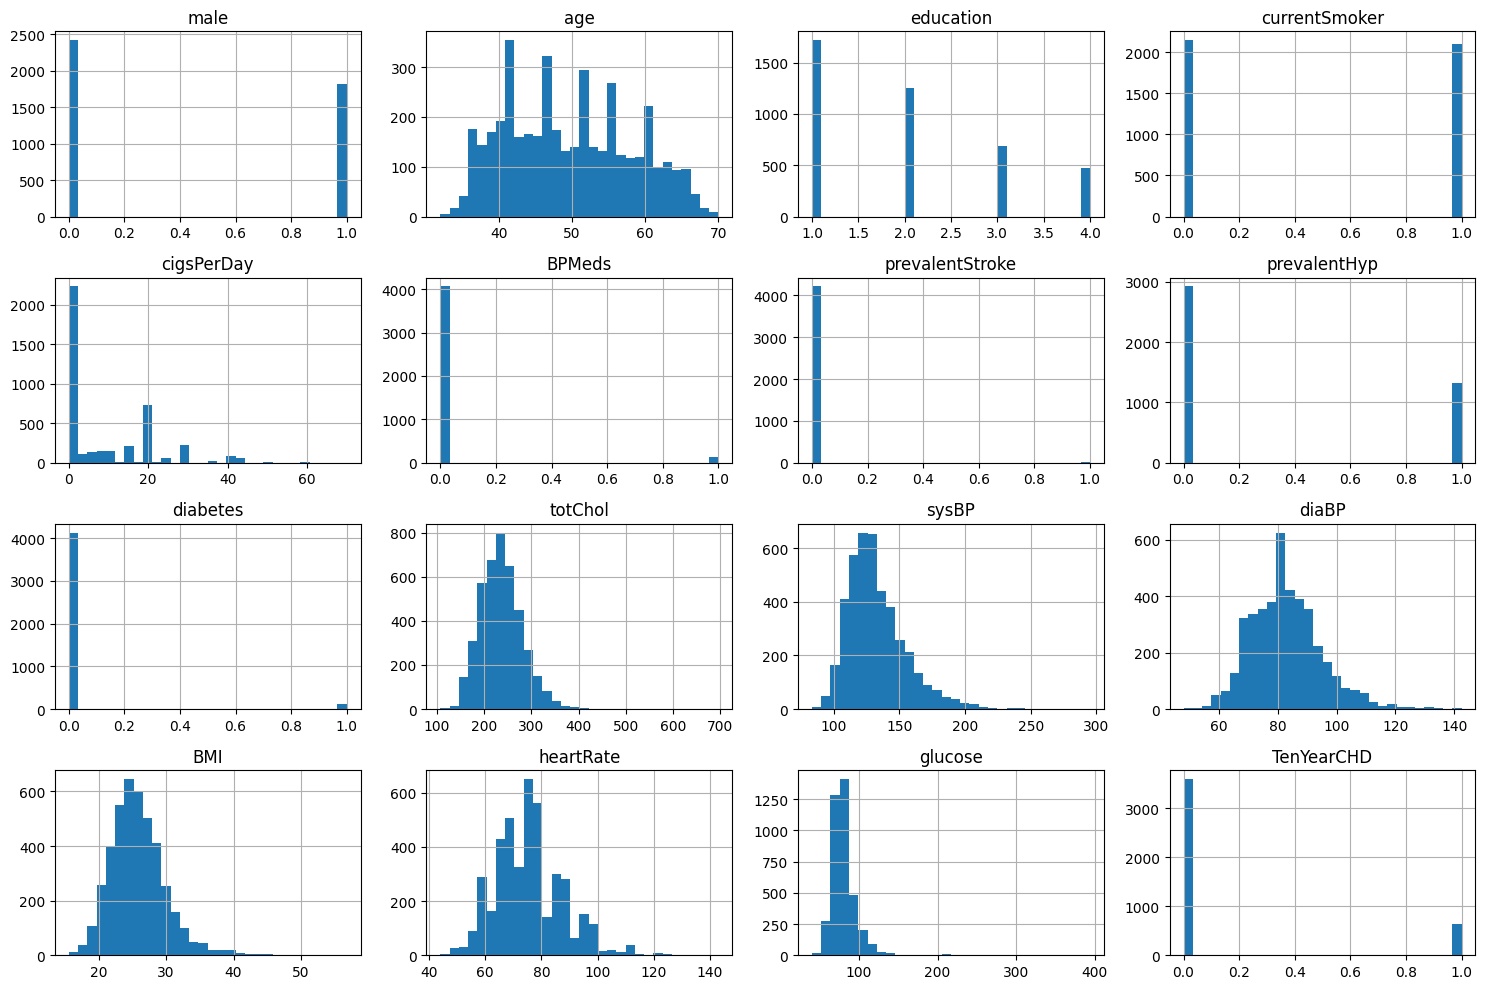

In [7]:
os.makedirs("framingham_plots", exist_ok=True)

df.hist(figsize=(15, 10), bins=30)
plt.tight_layout()
plt.savefig("framingham_plots/eda_feature_distributions_overview.png", bbox_inches="tight")
plt.show()

# EDA

TenYearCHD
0    0.848113
1    0.151887
Name: proportion, dtype: float64


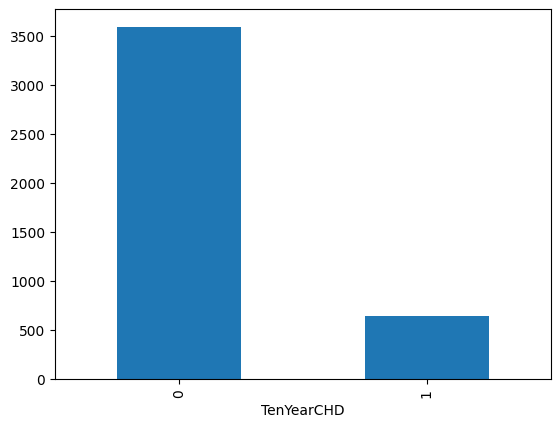

In [8]:
# class distribution
print(df['TenYearCHD'].value_counts(normalize=True))
df['TenYearCHD'].value_counts().plot(kind='bar')
plt.savefig("framingham_plots/eda_target_distribution.png", bbox_inches="tight")

## Target Distribution

The target variable TenYearCHD is clearly imbalanced: approximately 84.8% of patients do not develop CHD within 10 years, while only 15.2% do.

This imbalance has several important implications:

- Accuracy alone will not be a reliable evaluation metric, as a naive model predicting only the majority class would already achieve high accuracy.
- Metrics such as ROC-AUC, precision, recall, and F1-score will be more informative.
- During modelling, techniques such as class weighting or resampling may be necessary to ensure the minority class is properly learned.

In [9]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
male,4240.0,0.429245,0.495027,0.00,0.00,0.0,1.00,1.0
age,4240.0,49.580189,8.572942,32.00,42.00,49.0,56.00,70.0
education,4135.0,1.979444,1.019791,1.00,1.00,2.0,3.00,4.0
currentSmoker,4240.0,0.494104,0.500024,0.00,0.00,0.0,1.00,1.0
cigsPerDay,4211.0,9.005937,11.922462,0.00,0.00,0.0,20.00,70.0
BPMeds,4187.0,0.029615,0.169544,0.00,0.00,0.0,0.00,1.0
prevalentStroke,4240.0,0.005896,0.076569,0.00,0.00,0.0,0.00,1.0
prevalentHyp,4240.0,0.310613,0.462799,0.00,0.00,0.0,1.00,1.0
diabetes,4240.0,0.025708,0.158280,0.00,0.00,0.0,0.00,1.0
totChol,4190.0,236.699523,44.591284,107.00,206.00,234.0,263.00,696.0


## Feature Summary Statistics

The dataset contains a mix of binary, ordinal, and continuous variables:

- **Binary variables** (e.g., male, currentSmoker, diabetes, TenYearCHD) are encoded as 0/1 indicators.
- **Ordinal variables**, such as education, represent ordered categories.
- **Continuous variables** (e.g., age, totChol, sysBP, BMI, glucose) capture physiological measurements.

Several observations are noteworthy:

- The average age is around 49.6 years, with a range from 32 to 70, indicating a middle-aged population.
- Clinical variables such as sysBP, totChol, and glucose show relatively wide ranges, suggesting potential outliers or skewed distributions.
- Some features, such as cigsPerDay, have a median of 0 but a high maximum value, indicating a large proportion of non-smokers alongside a smaller group of heavy smokers.
- The target variable mean (~0.152) aligns with the previously observed class imbalance.

These differences in scale and distribution suggest that preprocessing steps such as scaling and possibly outlier handling will be important for certain models.

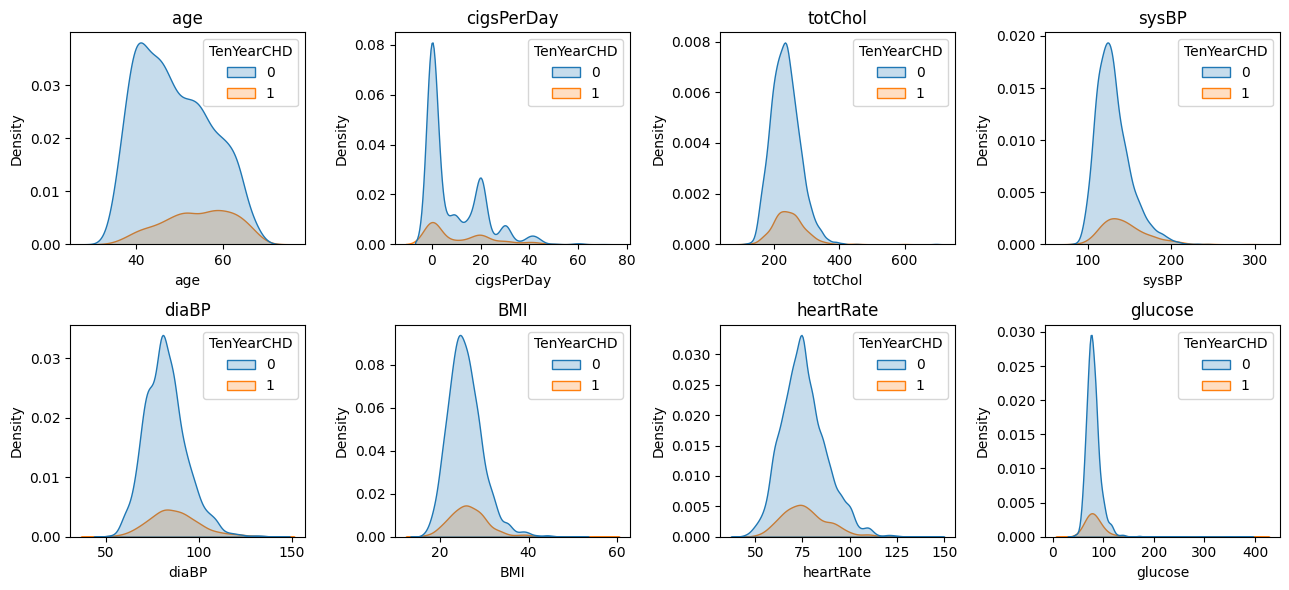

In [10]:
# KDE plots (feature vs target analysis)

num_cols = ['age', 'cigsPerDay', 'totChol', 'sysBP', 'diaBP', 'BMI', 'heartRate', 'glucose']

fig, axes = plt.subplots(2, 4, figsize=(13, 6))

for i, col in enumerate(num_cols):
    ax = axes[i // 4, i % 4]
    sns.kdeplot(data=df, x=col, hue='TenYearCHD', fill=True, ax=ax)
    ax.set_title(col)

plt.tight_layout()
plt.savefig("framingham_plots/eda_continuous_feature_vs_target.png", bbox_inches="tight")
plt.show()

## Feature vs Target Analysis

Overall, the most informative features appear to be **age, blood pressure, and (to a lesser extent) cholesterol and glucose**.  However, most features exhibit substantial overlap between classes, indicating that CHD risk is not driven by a single variable but rather by a combination of factors. This supports the use of multivariate models to capture interactions and nonlinear relationships.

Additionally, the presence of skewed distributions and potential outliers suggests that transformations or robust modelling approaches may improve performance.

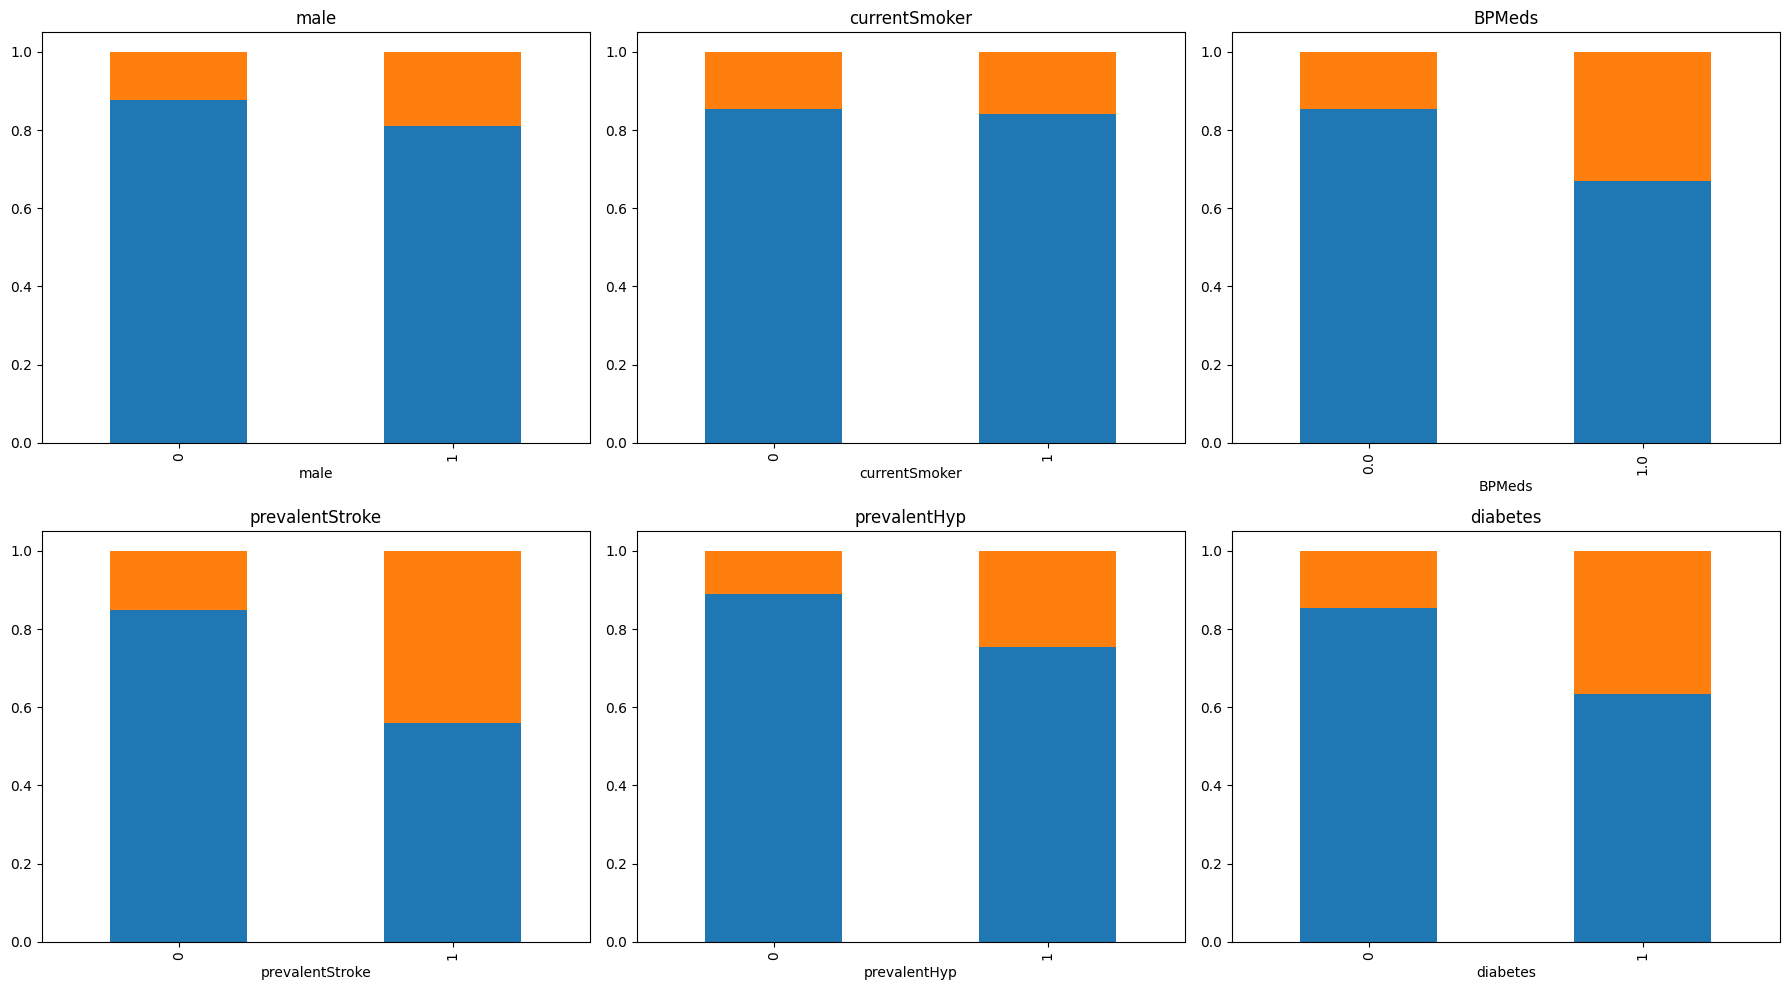

In [11]:
# categorical features vs target

cat_cols = ['male', 'currentSmoker', 'BPMeds', 'prevalentStroke', 'prevalentHyp', 'diabetes']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for i, col in enumerate(cat_cols):
    ax = axes[i // 3, i % 3]
    pd.crosstab(df[col], df['TenYearCHD'], normalize='index').plot(
        kind='bar', stacked=True, ax=ax, legend=False
    )
    ax.set_title(col)

plt.tight_layout()
plt.savefig("framingham_plots/eda_categorical_feature_vs_target.png", bbox_inches="tight")
plt.show()

## Categorical Features vs Target

To analyze categorical variables, we compare the proportion of patients who develop CHD within each category. The stacked bar plots show the relative frequency of positive and negative outcomes for each group.

### Key Observations:

Several categorical features show clear differences in CHD risk:

- **Sex (male)**: Males exhibit a higher proportion of CHD compared to females, indicating gender as an important risk factor.
- **Blood pressure medication (BPMeds)**: Patients on medication show a substantially higher CHD rate. This likely reflects underlying hypertension rather than a causal effect of the medication itself.
- **Prevalent stroke (prevalentStroke)**: Individuals with a history of stroke have a markedly higher CHD risk, suggesting strong comorbidity between cardiovascular conditions.
- **Hypertension (prevalentHyp)**: Clear increase in CHD prevalence among hypertensive patients.
- **Diabetes**: One of the strongest signals — diabetic patients show significantly higher CHD risk, consistent with known clinical evidence.

Some features appear less informative:

- **Current smoker (currentSmoker)**: The difference between smokers and non-smokers is relatively small in this representation. This may indicate that smoking intensity (cigsPerDay) captures the effect more effectively than a simple binary indicator.

### Interpretation

Categorical variables related to existing health conditions (e.g., hypertension, diabetes, prior stroke) show stronger associations with CHD than behavioral indicators alone.

This suggests that:
- Clinical history variables are likely to be highly predictive features.
- Some variables (e.g., BPMeds) may act as proxies for underlying conditions rather than independent risk factors.

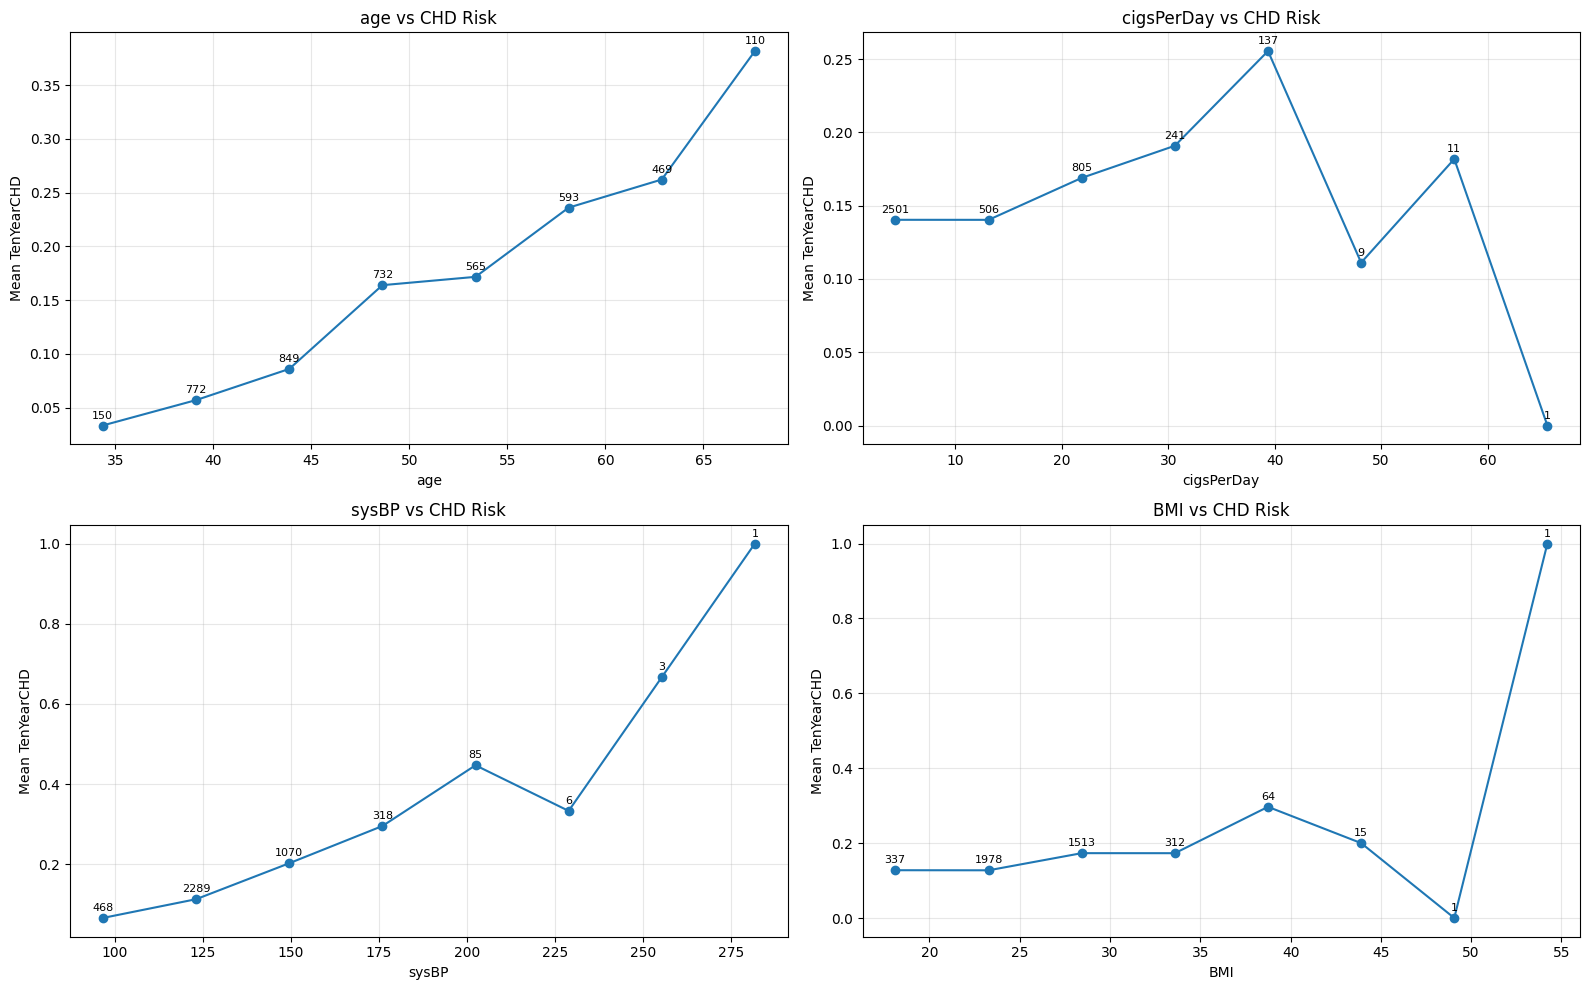

In [12]:
def plot_binned_risk(ax, df, feature, bins=8):
    temp = df[[feature, 'TenYearCHD']].dropna().copy()
    
    # Create bins
    temp['bin'] = pd.cut(temp[feature], bins=bins)
    
    # Aggregate risk and count per bin
    grouped = temp.groupby('bin', observed=False)['TenYearCHD'].agg(['mean', 'count']).reset_index()
    
    # Use bin midpoints for cleaner x-axis
    grouped['mid'] = grouped['bin'].apply(lambda x: x.mid)
    
    ax.plot(grouped['mid'], grouped['mean'], marker='o')
    ax.set_title(f'{feature} vs CHD Risk')
    ax.set_xlabel(feature)
    ax.set_ylabel('Mean TenYearCHD')
    ax.grid(True, alpha=0.3)
    
    # Optional: annotate counts per bin
    for x, y, c in zip(grouped['mid'], grouped['mean'], grouped['count']):
        ax.annotate(str(c), (x, y), textcoords="offset points", xytext=(0, 5), ha='center', fontsize=8)

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

plot_binned_risk(axes[0, 0], df, 'age', bins=8)
plot_binned_risk(axes[0, 1], df, 'cigsPerDay', bins=8)
plot_binned_risk(axes[1, 0], df, 'sysBP', bins=8)
plot_binned_risk(axes[1, 1], df, 'BMI', bins=8)

plt.tight_layout()
plt.savefig("framingham_plots/eda_risk_by_feature.png", bbox_inches="tight")
plt.show()

## Risk Analysis by Feature (Binned)

To better understand how individual features relate to CHD risk, we group continuous variables into bins and compute the average probability of TenYearCHD within each bin.

This provides a more direct view of how risk changes across different value ranges.

### Key Observations:

- **Age**: There is a strong and consistent increase in CHD risk with age. The relationship appears close to monotonic, confirming age as one of the most important predictors.

- **Systolic blood pressure (sysBP)**: CHD risk increases with higher blood pressure levels, particularly beyond ~140 mmHg. This aligns well with clinical expectations regarding hypertension.

- **Cigarettes per day (cigsPerDay)**: The relationship is less stable. Risk appears to increase up to moderate-to-heavy smoking levels, but becomes noisy at extreme values. This is likely due to small sample sizes in higher bins.

- **BMI**: The relationship is weak and non-monotonic. While there is a slight increase in risk at higher BMI ranges, the signal is inconsistent.

### Important Consideration: Sample Size Effects

The numbers annotated above each point indicate the number of observations in each bin. Some bins, particularly at extreme values (e.g., very high BMI or very high blood pressure), contain very few samples.

This leads to:
- artificially high or low risk estimates (e.g., risk ≈ 1.0 with only 1 observation)
- unstable and noisy trends

Therefore, extreme points should be interpreted with caution, and overall trends are more informative than individual outliers.

### Interpretation

The clearest and most reliable relationships are observed for **age** and **systolic blood pressure**, both showing strong positive associations with CHD risk.

Other variables, such as **BMI** and **smoking intensity**, exhibit weaker or noisier relationships, suggesting that their predictive value may emerge more clearly in combination with other features rather than in isolation.

This analysis reinforces the need for multivariate models while also highlighting which features are likely to carry the strongest signal.

<Axes: >

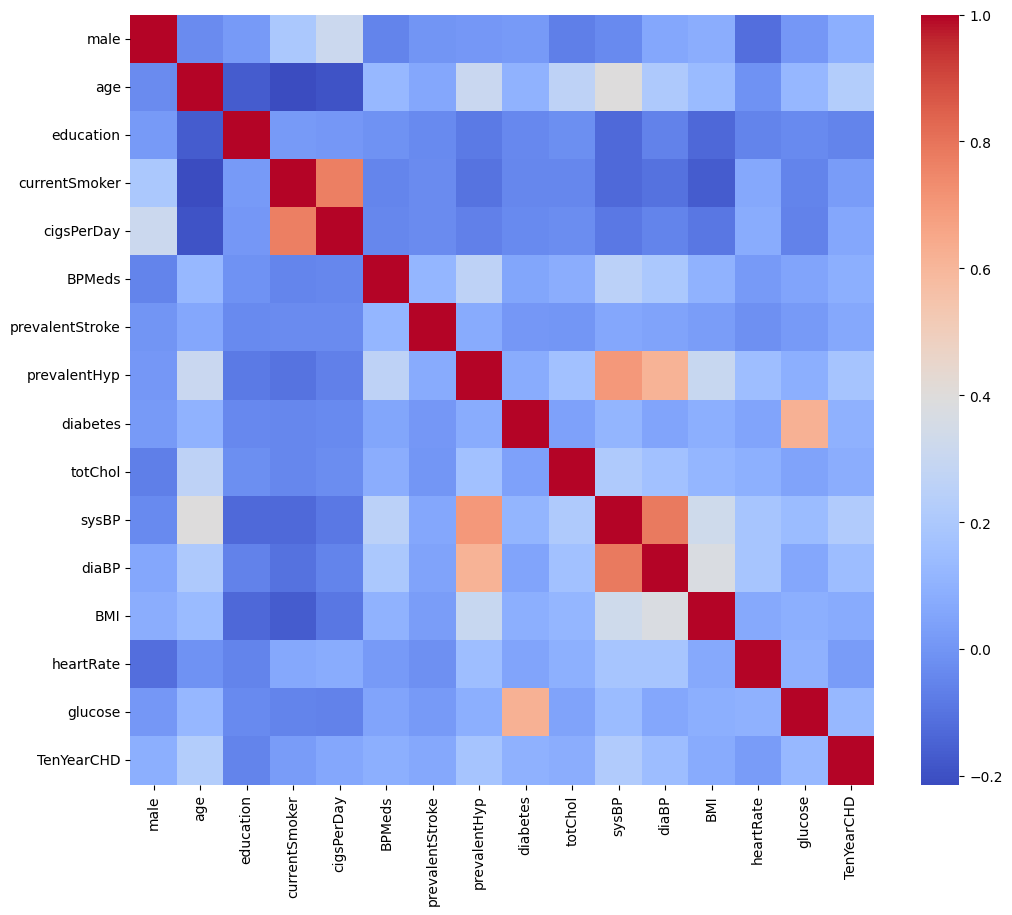

In [13]:
# Correlation Analysis

numeric_df = df.select_dtypes(include=['number'])

plt.figure(figsize=(12, 10))
plt.savefig("framingham_plots/eda_correlation.png", bbox_inches="tight")
sns.heatmap(numeric_df.corr(), cmap='coolwarm')

## Correlation Analysis

To further understand relationships between variables, we examine the Pearson correlation matrix for all numerical features.

### Key Observations:

- **Strong correlations between predictors**:
  - sysBP and diaBP show a high positive correlation, which is expected as both measure blood pressure.
  - currentSmoker and cigsPerDay are strongly correlated, indicating redundancy between a binary smoking indicator and smoking intensity.
  - prevalentHyp is moderately correlated with both sysBP and diaBP, reflecting its clinical definition.

- **Correlation with target (TenYearCHD)**:
  - The strongest positive correlations with CHD risk appear for:
    - age
    - sysBP
    - prevalentHyp
  - Other features such as glucose, diabetes, and totChol show weaker but still positive associations.
  - Most correlations are relatively modest, suggesting that no single feature dominates prediction.

### Interpretation

The absence of very strong correlations with the target indicates that CHD risk is influenced by multiple interacting factors rather than a single dominant variable. This reinforces the need for multivariate modelling approaches.

At the same time, the presence of correlated predictors (e.g., blood pressure variables, smoking-related variables) introduces **multicollinearity**, which can:

- Affect coefficient stability in linear models such as logistic regression
- Reduce interpretability if not handled properly

However, tree-based models (e.g., Random Forest, Gradient Boosting) are generally more robust to such correlations.

Overall, the correlation structure confirms earlier findings: **age and blood pressure-related variables are central to CHD risk**, while other features contribute more subtle signals.

In [14]:
# Missing values and outlier analysis

for col in ['glucose', 'education', 'BPMeds']:
    df[col + '_missing'] = df[col].isnull().astype(int)
    print(pd.crosstab(df[col + '_missing'], df['TenYearCHD'], normalize='index'))


TenYearCHD              0         1
glucose_missing                    
0                0.845794  0.154206
1                0.871134  0.128866
TenYearCHD                0         1
education_missing                    
0                  0.848126  0.151874
1                  0.847619  0.152381
TenYearCHD             0         1
BPMeds_missing                    
0               0.848818  0.151182
1               0.792453  0.207547


<Axes: xlabel='glucose', ylabel='TenYearCHD'>

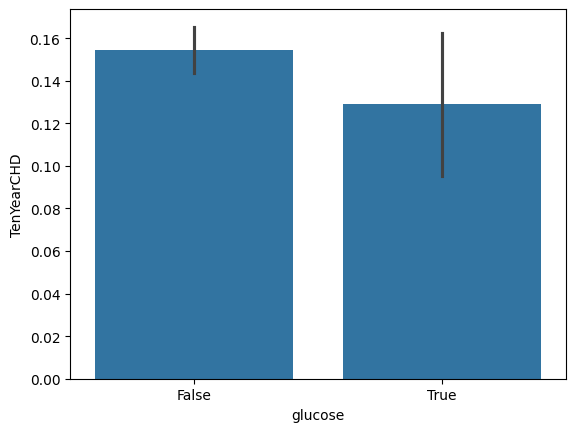

In [15]:
sns.barplot(x=df['glucose'].isnull(), y=df['TenYearCHD'])

### Missingness as Signal

To assess whether missing values carry information, we compare CHD prevalence between observations with and without missing values for selected features.

- **Glucose**: Missing values are associated with a slightly lower CHD rate.
- **BPMeds**: Missingness shows a noticeable difference in CHD prevalence, suggesting it may not be random.
- **Education**: No meaningful difference is observed.

This indicates that missingness may contain predictive signal for some variables. As a result, introducing **missingness indicators** during preprocessing could improve model performance.

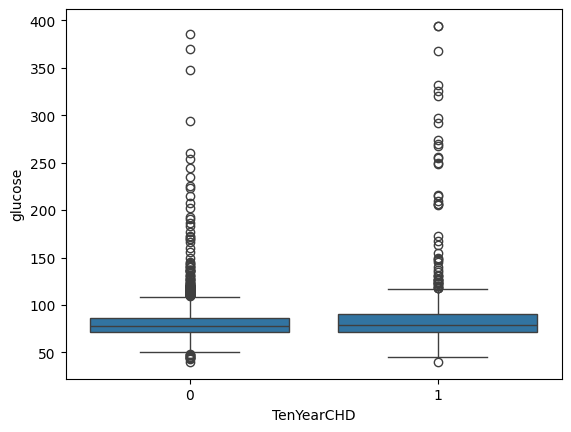

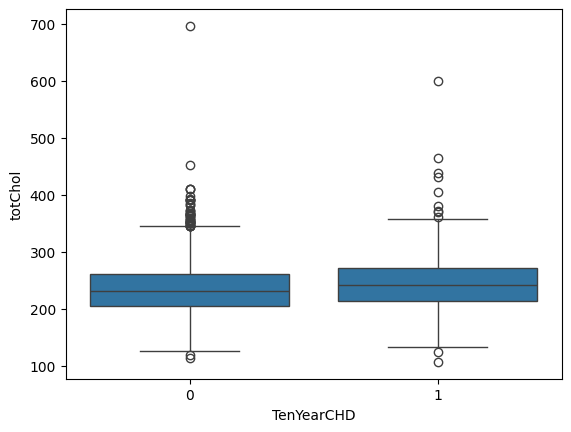

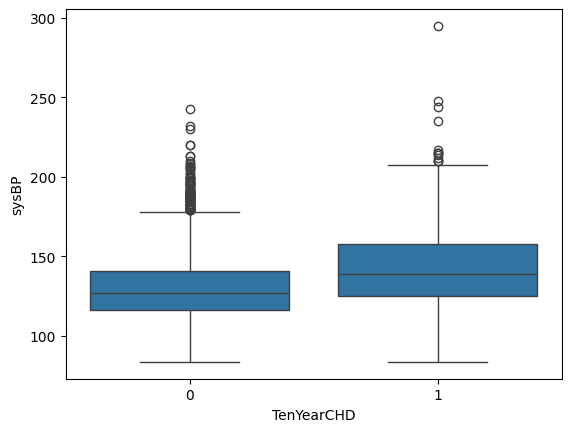

In [16]:
# Outlier Analysis

for col in ['glucose', 'totChol', 'sysBP']:
    sns.boxplot(x='TenYearCHD', y=col, data=df)
    plt.show()

### Outlier Analysis

The boxplots for glucose, totChol, and sysBP show numerous high-value outliers, particularly in the CHD-positive group.

Across all three features, patients with CHD tend to have:
- higher median values  
- greater variability  
- more extreme observations  

These patterns are consistent with clinical expectations, where elevated glucose, cholesterol, and blood pressure are associated with increased cardiovascular risk.

Although these values appear as statistical outliers, they are likely **meaningful rather than erroneous**, so removing them could discard important signal. Instead, we will rely on robust models and appropriate scaling where needed.

# Preprocessing

In [17]:
# Define X and y
X = df.drop("TenYearCHD", axis=1).copy()
y = df["TenYearCHD"].copy()

# Remove any leftover manually created missing-indicator columns
leaked_missing_cols = [col for col in X.columns if col.endswith("_missing")]
if leaked_missing_cols:
    print("Removing leftover columns:", leaked_missing_cols)
    X = X.drop(columns=leaked_missing_cols)

# Final holdout split: never touch until the very end
X_dev, X_test_final, y_dev, y_test_final = train_test_split(
    X,
    y,
    test_size=0.10,
    random_state=42,
    stratify=y
)

print("Development set shape:", X_dev.shape)
print("Final holdout shape:", X_test_final.shape)
print("\nTarget rate:")
print("y_dev:", y_dev.mean().round(4))
print("y_test_final:", y_test_final.mean().round(4))

Removing leftover columns: ['glucose_missing', 'education_missing', 'BPMeds_missing']
Development set shape: (3816, 15)
Final holdout shape: (424, 15)

Target rate:
y_dev: 0.152
y_test_final: 0.1509


In [18]:
# Columns with missingness that we explicitly want to track
missing_indicator_cols = ["glucose", "education", "BPMeds"]

# Columns to clip using training quantiles
clip_cols = ["glucose", "totChol", "sysBP"]

# Continuous columns to impute + scale
continuous_cols = [
    "age", "glucose", "totChol", "cigsPerDay",
    "BMI", "heartRate", "sysBP", "diaBP"
]

# Categorical / binary columns to impute with most frequent
binary_or_cat_cols = ["education", "BPMeds"]

# Everything else that should pass through unchanged
passthrough_cols = [
    col for col in X.columns
    if col not in continuous_cols + binary_or_cat_cols
]
    
print("Continuous:", continuous_cols)
print("Binary/categorical:", binary_or_cat_cols)
print("Passthrough:", passthrough_cols)
print("Missing indicators:", missing_indicator_cols)

Continuous: ['age', 'glucose', 'totChol', 'cigsPerDay', 'BMI', 'heartRate', 'sysBP', 'diaBP']
Binary/categorical: ['education', 'BPMeds']
Passthrough: ['male', 'currentSmoker', 'prevalentStroke', 'prevalentHyp', 'diabetes']
Missing indicators: ['glucose', 'education', 'BPMeds']


In [19]:
class QuantileClipper(BaseEstimator, TransformerMixin):
    """
    Clip selected numeric columns using training-set quantiles.
    Preserves column names and supports get_feature_names_out.
    """
    def __init__(self, lower_quantile=0.01, upper_quantile=0.99):
        self.lower_quantile = lower_quantile
        self.upper_quantile = upper_quantile

    def fit(self, X, y=None):
        X_df = pd.DataFrame(X).copy()
        self.feature_names_in_ = X_df.columns.to_list()
        self.lower_bounds_ = X_df.quantile(self.lower_quantile)
        self.upper_bounds_ = X_df.quantile(self.upper_quantile)
        return self

    def transform(self, X):
        X_df = pd.DataFrame(X, columns=self.feature_names_in_).copy()
        X_df = X_df[self.feature_names_in_]
        
        for col in self.feature_names_in_:
            X_df[col] = X_df[col].clip(
                lower=self.lower_bounds_[col],
                upper=self.upper_bounds_[col]
            )
        return X_df

    def get_feature_names_out(self, input_features=None):
        if input_features is None:
            input_features = self.feature_names_in_
        return np.array(input_features, dtype=object)


class MissingFlagger(BaseEstimator, TransformerMixin):
    """
    Create explicit missingness indicator columns for selected variables.
    """
    def fit(self, X, y=None):
        X_df = pd.DataFrame(X).copy()
        self.feature_names_in_ = X_df.columns.to_list()
        return self

    def transform(self, X):
        X_df = pd.DataFrame(X, columns=self.feature_names_in_).copy()
        X_df = X_df[self.feature_names_in_]
        
        out = pd.DataFrame(index=X_df.index)
        for col in self.feature_names_in_:
            out[f"{col}_missing"] = X_df[col].isna().astype(int)
        return out

    def get_feature_names_out(self, input_features=None):
        if input_features is None:
            input_features = self.feature_names_in_
        return np.array([f"{col}_missing" for col in input_features], dtype=object)

In [20]:
# Continuous features: clip -> median impute -> scale
continuous_pipeline = Pipeline([
    ("clip", QuantileClipper(lower_quantile=0.01, upper_quantile=0.99)),
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Binary/categorical features: most-frequent imputation
binary_cat_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent"))
])

# Missingness indicators: created BEFORE imputation
missing_indicator_pipeline = Pipeline([
    ("flagger", MissingFlagger())
])

# Full preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ("continuous", continuous_pipeline, continuous_cols),
        ("binary_cat", binary_cat_pipeline, binary_or_cat_cols),
        ("missing_flags", missing_indicator_pipeline, missing_indicator_cols),
        ("passthrough", "passthrough", passthrough_cols)
    ],
    remainder="drop",
    verbose_feature_names_out=True
)

In [21]:
X_dev_processed = preprocessor.fit_transform(X_dev, y_dev)
X_test_final_processed = preprocessor.transform(X_test_final)

print("Processed development shape:", X_dev_processed.shape)
print("Processed final holdout shape:", X_test_final_processed.shape)

feature_names = preprocessor.get_feature_names_out()
print("\nFirst 20 feature names:")
print(feature_names[:20])

print("\nTotal missing values in processed development set:")
print(pd.isnull(X_dev_processed).sum())

print("\nTotal missing values in processed final holdout set:")
print(pd.isnull(X_test_final_processed).sum())

Processed development shape: (3816, 18)
Processed final holdout shape: (424, 18)

First 20 feature names:
['continuous__age' 'continuous__glucose' 'continuous__totChol'
 'continuous__cigsPerDay' 'continuous__BMI' 'continuous__heartRate'
 'continuous__sysBP' 'continuous__diaBP' 'binary_cat__education'
 'binary_cat__BPMeds' 'missing_flags__glucose_missing'
 'missing_flags__education_missing' 'missing_flags__BPMeds_missing'
 'passthrough__male' 'passthrough__currentSmoker'
 'passthrough__prevalentStroke' 'passthrough__prevalentHyp'
 'passthrough__diabetes']

Total missing values in processed development set:
0

Total missing values in processed final holdout set:
0


In [22]:
print([col for col in X.columns if col.endswith("_missing")])

[]


## Data Preprocessing Summary

The preprocessing steps were guided by insights from exploratory data analysis and aimed at preparing the data for robust modelling.

- **Train-test split**: The data was split into 90/10 subsets using stratification to preserve class imbalance.

- **Missing values**:  
  Missingness indicators were added for selected features (glucose, BPMeds and education) where missingness showed predictive signal.  
  Missing values were then imputed using:
  - mode (categorical/binary features)
  - median (continuous features)

- **Outlier handling**:  
  Extreme values in key continuous variables were clipped to the 1st and 99th percentiles based on the training set to reduce the impact of outliers while preserving meaningful observations.

- **Feature scaling**:  
  All continuous features were standardized using training-set statistics to ensure compatibility with linear models.

Overall, the preprocessing pipeline balances robustness and simplicity while avoiding data leakage.

# Experimentation

In [23]:
def evaluate_model(model=None, X_test=None, y_test=None, thresholds=(0.5,), model_name=None, y_proba=None):
    """
    Universal evaluation function for binary classification.

    Works in two modes:
    1. Standard model mode:
       - pass model and X_test
    2. Precomputed probability mode:
       - pass y_proba directly

    Parameters
    ----------
    model : fitted classifier, optional
        Any fitted model with predict_proba().
    X_test : array-like, optional
        Test features for model-based evaluation.
    y_test : array-like
        True labels.
    thresholds : tuple
        Thresholds for converting probabilities to class predictions.
    model_name : str, optional
        Name shown in output.
    y_proba : array-like, optional
        Precomputed predicted probabilities for class 1.
    """
    if y_test is None:
        raise ValueError("y_test must be provided.")

    if y_proba is None:
        if model is None or X_test is None:
            raise ValueError("Provide either (model and X_test) or y_proba.")
        y_proba = model.predict_proba(X_test)[:, 1]

    if model_name is not None:
        print(f"\n=== {model_name} ===")

    roc_auc = roc_auc_score(y_test, y_proba)
    pr_auc = average_precision_score(y_test, y_proba)
    prevalence = np.mean(y_test)

    print(f"ROC-AUC: {roc_auc:.6f}")
    print(f"PR-AUC (Average Precision): {pr_auc:.6f}")
    print(f"Positive class prevalence: {prevalence:.6f}")

    for t in thresholds:
        y_pred = (y_proba >= t).astype(int)
        print(f"\nThreshold: {t}")
        print(classification_report(y_test, y_pred, zero_division=0))
        print(confusion_matrix(y_test, y_pred))

    return y_proba

## Logistic Regression

In [24]:
logreg_pipeline = Pipeline([
    ("preprocess", preprocessor),
    ("model", LogisticRegression(
        max_iter=3000,
        class_weight="balanced",
        random_state=42
    ))
])

In [25]:
X_train_dev, X_valid_dev, y_train_dev, y_valid_dev = train_test_split(
    X_dev,
    y_dev,
    test_size=0.2,
    stratify=y_dev,
    random_state=42
)

In [26]:
logreg_pipeline.fit(X_train_dev, y_train_dev)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocess', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('continuous', ...), ('binary_cat', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the differen

In [27]:
y_proba_lr = evaluate_model(
    model=logreg_pipeline,
    X_test=X_valid_dev,
    y_test=y_valid_dev,
    thresholds=(0.3, 0.4, 0.5, 0.6, 0.7),
    model_name="Logistic Regression"
)


=== Logistic Regression ===
ROC-AUC: 0.725987
PR-AUC (Average Precision): 0.342056
Positive class prevalence: 0.151832

Threshold: 0.3
              precision    recall  f1-score   support

           0       0.95      0.30      0.46       648
           1       0.19      0.91      0.31       116

    accuracy                           0.39       764
   macro avg       0.57      0.60      0.39       764
weighted avg       0.83      0.39      0.44       764

[[196 452]
 [ 11 105]]

Threshold: 0.4
              precision    recall  f1-score   support

           0       0.93      0.49      0.65       648
           1       0.22      0.79      0.34       116

    accuracy                           0.54       764
   macro avg       0.57      0.64      0.49       764
weighted avg       0.82      0.54      0.60       764

[[320 328]
 [ 24  92]]

Threshold: 0.5
              precision    recall  f1-score   support

           0       0.93      0.68      0.78       648
           1       0.28

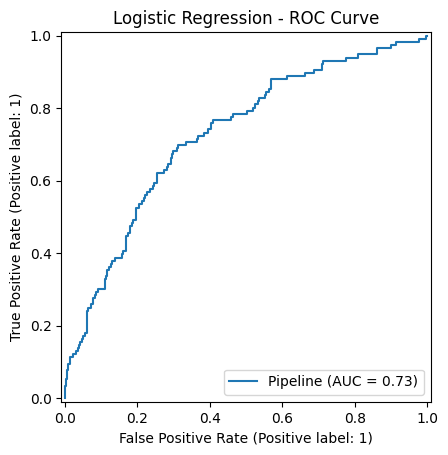

In [28]:
# ROC Curve
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_estimator(logreg_pipeline, X_valid_dev, y_valid_dev)
plt.title("Logistic Regression - ROC Curve")
plt.savefig("framingham_plots/experimentation_logistic_regression_roc.png", bbox_inches="tight")
plt.show()

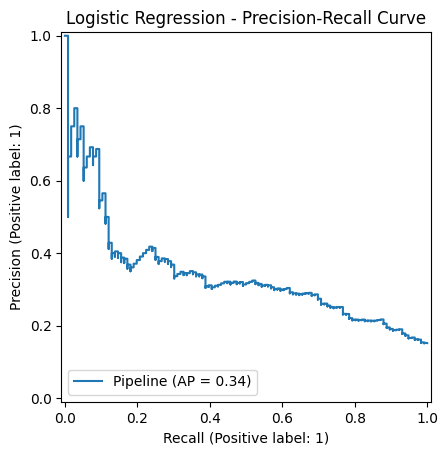

In [29]:
# Precision-Recall Curve

PrecisionRecallDisplay.from_estimator(logreg_pipeline, X_valid_dev, y_valid_dev)
plt.title("Logistic Regression - Precision-Recall Curve")
plt.savefig("framingham_plots/experimentation_logistic_regression_pr.png", bbox_inches="tight")
plt.show()

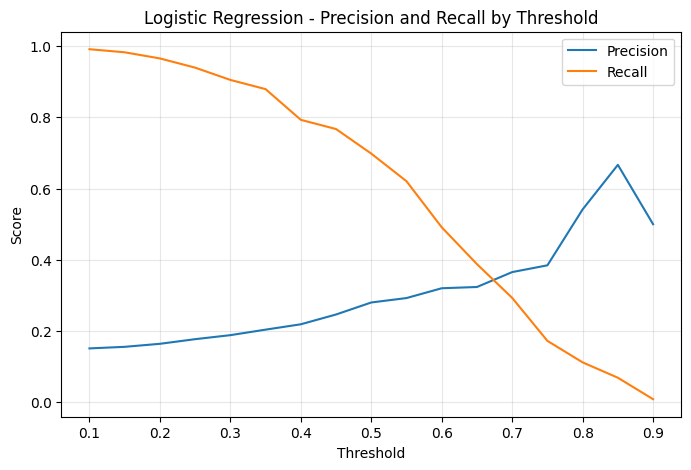

In [30]:
# Threshold curve
thresholds = np.arange(0.1, 0.91, 0.05)
precisions = []
recalls = []

y_proba = logreg_pipeline.predict_proba(X_valid_dev)[:, 1]

for t in thresholds:
    y_pred = (y_proba >= t).astype(int)
    precisions.append(precision_score(y_valid_dev, y_pred, zero_division=0))
    recalls.append(recall_score(y_valid_dev, y_pred, zero_division=0))

plt.figure(figsize=(8, 5))
plt.plot(thresholds, precisions, label="Precision")
plt.plot(thresholds, recalls, label="Recall")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Logistic Regression - Precision and Recall by Threshold")
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig("framingham_plots/experimentation_logistic_regression_precision-recall_by_threshold.png", bbox_inches="tight")
plt.show()

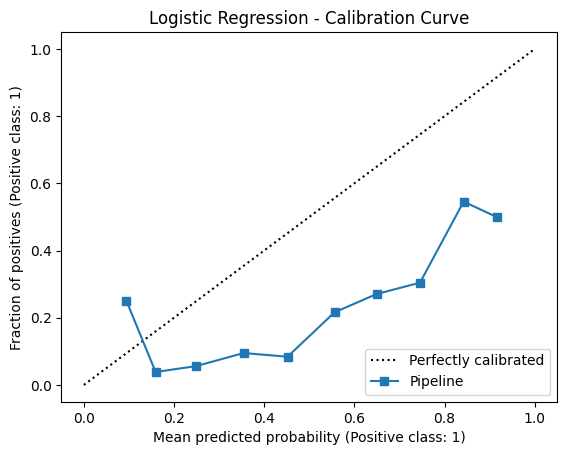

In [31]:
# Calibration curve

CalibrationDisplay.from_estimator(logreg_pipeline, X_valid_dev, y_valid_dev, n_bins=10)
plt.title("Logistic Regression - Calibration Curve")
plt.savefig("framingham_plots/experimentation_logistic_regression_calibration.png", bbox_inches="tight")
plt.show()

## Logistic Regression Baseline

As an initial model, logistic regression was trained using the full preprocessing pipeline. To account for class imbalance, class weights were set to `"balanced"`, increasing sensitivity to the minority (CHD-positive) class.

The model achieved a ROC-AUC of approximately 0.73, indicating moderate discriminative ability. In addition, the precision–recall performance (PR-AUC ≈ 0.34) is substantially higher than the baseline prevalence (~0.15), confirming that the model captures meaningful signal for identifying positive cases despite class imbalance.

At the default threshold (0.5), the model achieves a recall of approximately 0.70 for the positive class, with a precision of around 0.28. This reflects a trade-off typical for imbalanced medical data: the model is able to identify a majority of at-risk individuals but produces a considerable number of false positives.

Analysis across multiple thresholds shows a smooth and continuous precision–recall trade-off. Lower thresholds substantially increase recall (above 0.9) at the cost of very low precision, while higher thresholds improve precision but significantly reduce recall. The absence of a clear optimal threshold suggests that the choice of operating point should be guided by the specific application context, such as prioritizing sensitivity for screening versus precision for targeted interventions.

The precision–recall curve further indicates that the model is more effective as a broad screening tool than as a high-precision predictor: it can identify a large portion of positive cases but struggles to isolate a small, highly reliable high-risk group.

Finally, calibration analysis reveals that predicted probabilities are not well aligned with observed outcomes, with systematic deviations from perfect calibration. This suggests that while the model provides reasonable ranking of risk, its predicted probabilities should not yet be interpreted as accurate absolute risk estimates without additional calibration.

Overall, logistic regression provides a strong and interpretable baseline, capturing the main linear relationships in the data. However, its limitations in precision, calibration, and potential nonlinear effects highlight areas for further improvement.

## Random Forest, Gradient Boosting and XGBoost

In [32]:
rf_pipeline = Pipeline([
    ("preprocess", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=500,
        max_depth=4,
        min_samples_leaf=20,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ))
])

In [33]:
rf_pipeline.fit(X_train_dev, y_train_dev)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocess', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('continuous', ...), ('binary_cat', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the differen

In [34]:
y_proba_rf = evaluate_model(
    model=rf_pipeline,
    X_test=X_valid_dev,
    y_test=y_valid_dev,
    thresholds=(0.3, 0.4, 0.5, 0.6, 0.7),
    model_name="Random Forest"
)


=== Random Forest ===
ROC-AUC: 0.706152
PR-AUC (Average Precision): 0.326656
Positive class prevalence: 0.151832

Threshold: 0.3
              precision    recall  f1-score   support

           0       0.95      0.19      0.31       648
           1       0.17      0.94      0.29       116

    accuracy                           0.30       764
   macro avg       0.56      0.56      0.30       764
weighted avg       0.83      0.30      0.31       764

[[121 527]
 [  7 109]]

Threshold: 0.4
              precision    recall  f1-score   support

           0       0.93      0.41      0.57       648
           1       0.20      0.84      0.33       116

    accuracy                           0.48       764
   macro avg       0.57      0.62      0.45       764
weighted avg       0.82      0.48      0.53       764

[[266 382]
 [ 19  97]]

Threshold: 0.5
              precision    recall  f1-score   support

           0       0.91      0.69      0.78       648
           1       0.26      

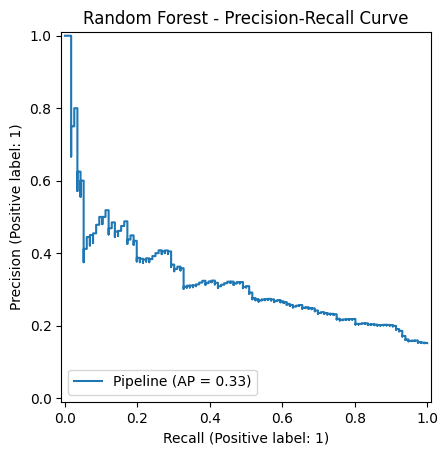

In [35]:
# PR Curve

PrecisionRecallDisplay.from_estimator(rf_pipeline, X_valid_dev, y_valid_dev)
plt.title("Random Forest - Precision-Recall Curve")
plt.savefig("framingham_plots/experimentation_rf_pr.png", bbox_inches="tight")
plt.show()

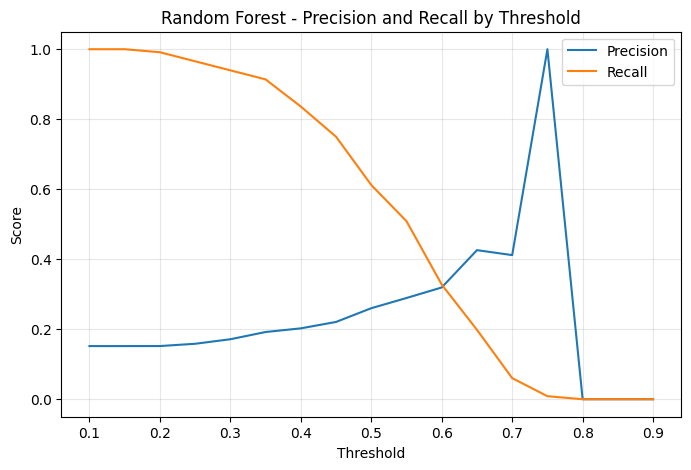

In [36]:
# Threshold curve
thresholds = np.arange(0.1, 0.91, 0.05)
precisions = []
recalls = []

y_proba = rf_pipeline.predict_proba(X_valid_dev)[:, 1]

for t in thresholds:
    y_pred = (y_proba >= t).astype(int)
    precisions.append(precision_score(y_valid_dev, y_pred, zero_division=0))
    recalls.append(recall_score(y_valid_dev, y_pred, zero_division=0))

plt.figure(figsize=(8, 5))
plt.plot(thresholds, precisions, label="Precision")
plt.plot(thresholds, recalls, label="Recall")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Random Forest - Precision and Recall by Threshold")
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig("framingham_plots/experimentation_rf_precision-recall_by_threshold.png", bbox_inches="tight")
plt.show()

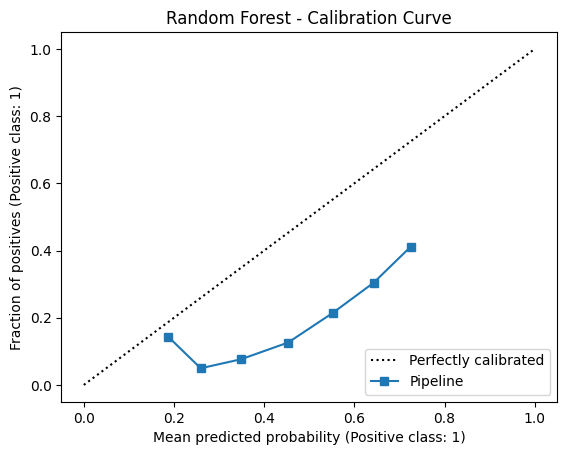

In [37]:
# Calibration Curve

CalibrationDisplay.from_estimator(rf_pipeline, X_valid_dev, y_valid_dev, n_bins=10)
plt.title("Random Forest - Calibration Curve")
plt.savefig("framingham_plots/experimentation_rf_calibration.png", bbox_inches="tight")
plt.show()

## Random Forest Model

Random Forest classifiers were evaluated using multiple configurations, including a more regularized variant with constrained tree depth and larger minimum leaf sizes. These adjustments were intended to reduce overfitting and improve generalization.

However, the best-performing Random Forest model achieved a ROC-AUC of approximately 0.71 and a PR-AUC of approximately 0.33, both slightly below the corresponding logistic regression baseline (ROC-AUC ≈ 0.73, PR-AUC ≈ 0.34). This indicates that Random Forest did not improve either overall discrimination or performance on the minority (CHD-positive) class.

Threshold analysis further confirms this pattern. At the default threshold (0.5), Random Forest achieves slightly lower recall (~0.63 vs ~0.70) and comparable precision (~0.27) relative to logistic regression, representing a less favorable trade-off. At higher thresholds, precision increases but at the cost of a rapid collapse in recall, with no meaningful high-confidence prediction region emerging.

The precision–recall curve closely mirrors that of logistic regression but remains consistently lower across most recall levels, suggesting that the model does not capture additional useful structure in the data. This indicates that the underlying signal may be largely linear or already sufficiently captured by simpler models.

Calibration analysis reveals an additional limitation: Random Forest produces less reliable probability estimates, with noticeable deviations from perfect calibration across probability bins. This is particularly important in a risk prediction setting, where well-calibrated probabilities are essential for meaningful interpretation.

Overall, the results suggest that increasing model complexity through nonlinear tree-based methods does not yield meaningful performance gains for this dataset. Instead, logistic regression remains preferable due to its slightly better performance, greater stability, and superior interpretability.

In [38]:
gb_pipeline = Pipeline([
    ("preprocess", preprocessor),
    ("model", GradientBoostingClassifier(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    ))
])

In [39]:
sample_weights = compute_sample_weight(
    class_weight="balanced",
    y=y_train_dev
)

gb_pipeline.fit(
    X_train_dev,
    y_train_dev,
    model__sample_weight=sample_weights
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocess', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('continuous', ...), ('binary_cat', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the differen

In [40]:
y_proba_gb = evaluate_model(
    model=gb_pipeline,
    X_test=X_valid_dev,
    y_test=y_valid_dev,
    thresholds=(0.3, 0.4, 0.5, 0.6, 0.7),
    model_name="Gradient Boosting"
)


=== Gradient Boosting ===
ROC-AUC: 0.654960
PR-AUC (Average Precision): 0.248997
Positive class prevalence: 0.151832

Threshold: 0.3
              precision    recall  f1-score   support

           0       0.93      0.34      0.50       648
           1       0.19      0.84      0.31       116

    accuracy                           0.42       764
   macro avg       0.56      0.59      0.40       764
weighted avg       0.81      0.42      0.47       764

[[223 425]
 [ 18  98]]

Threshold: 0.4
              precision    recall  f1-score   support

           0       0.91      0.52      0.66       648
           1       0.21      0.71      0.32       116

    accuracy                           0.55       764
   macro avg       0.56      0.61      0.49       764
weighted avg       0.80      0.55      0.61       764

[[338 310]
 [ 34  82]]

Threshold: 0.5
              precision    recall  f1-score   support

           0       0.90      0.69      0.78       648
           1       0.24  

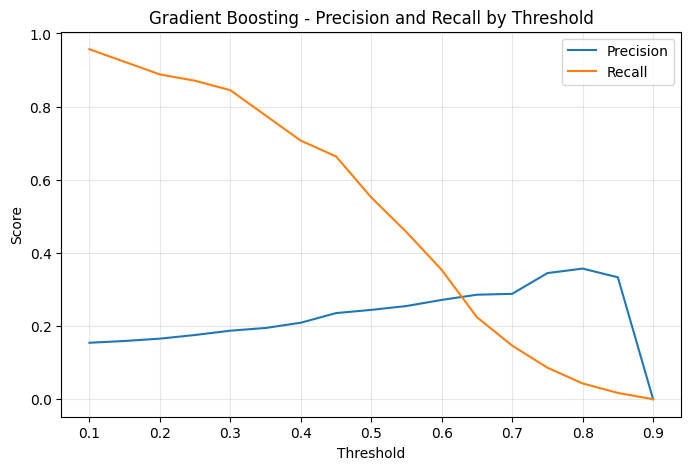

In [41]:
# Threshold curve
thresholds = np.arange(0.1, 0.91, 0.05)
precisions = []
recalls = []

y_proba = gb_pipeline.predict_proba(X_valid_dev)[:, 1]

for t in thresholds:
    y_pred = (y_proba >= t).astype(int)
    precisions.append(precision_score(y_valid_dev, y_pred, zero_division=0))
    recalls.append(recall_score(y_valid_dev, y_pred, zero_division=0))

plt.figure(figsize=(8, 5))
plt.plot(thresholds, precisions, label="Precision")
plt.plot(thresholds, recalls, label="Recall")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Gradient Boosting - Precision and Recall by Threshold")
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig("framingham_plots/experimentation_gb_precision-recall_by_threshold.png", bbox_inches="tight")
plt.show()

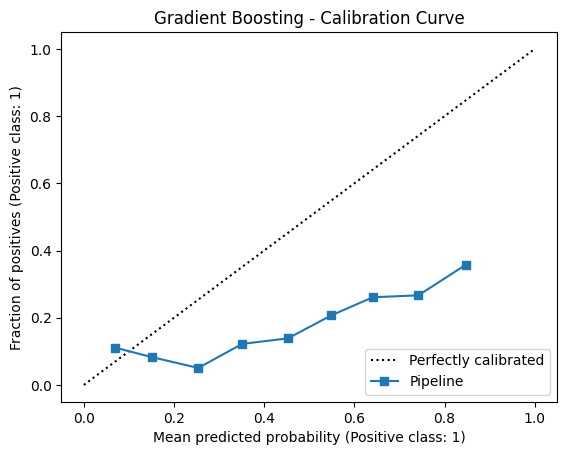

In [42]:
# Calibration curve

CalibrationDisplay.from_estimator(gb_pipeline, X_valid_dev, y_valid_dev, n_bins=10)
plt.title("Gradient Boosting - Calibration Curve")
plt.savefig("framingham_plots/experimentation_gb_calibration_curve.png", bbox_inches="tight")
plt.show()

In [43]:
# Make mistakes on class 1 ~5.6x more important
neg = (y_train_dev == 0).sum()
pos = (y_train_dev == 1).sum()
scale_pos_weight = neg / pos

print("scale_pos_weight:", scale_pos_weight)

scale_pos_weight: 5.577586206896552


In [44]:
xgb_pipeline = Pipeline([
    ("preprocess", preprocessor),
    ("model", XGBClassifier(
        n_estimators=300,
        max_depth=3,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.0,
        reg_lambda=1.0,
        min_child_weight=5,
        gamma=0,
        objective="binary:logistic",
        eval_metric="logloss",
        scale_pos_weight=scale_pos_weight,
        random_state=42
    ))
])

In [45]:
xgb_pipeline.fit(X_train_dev, y_train_dev)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocess', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('continuous', ...), ('binary_cat', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the differen

In [46]:
y_proba_xgb = evaluate_model(
    model=xgb_pipeline,
    X_test=X_valid_dev,
    y_test=y_valid_dev,
    thresholds=(0.3, 0.4, 0.5, 0.6, 0.7),
    model_name="XGBoost"
)


=== XGBoost ===
ROC-AUC: 0.648002
PR-AUC (Average Precision): 0.270536
Positive class prevalence: 0.151832

Threshold: 0.3
              precision    recall  f1-score   support

           0       0.90      0.38      0.54       648
           1       0.18      0.77      0.29       116

    accuracy                           0.44       764
   macro avg       0.54      0.58      0.42       764
weighted avg       0.79      0.44      0.50       764

[[249 399]
 [ 27  89]]

Threshold: 0.4
              precision    recall  f1-score   support

           0       0.90      0.54      0.68       648
           1       0.21      0.66      0.31       116

    accuracy                           0.56       764
   macro avg       0.55      0.60      0.50       764
weighted avg       0.79      0.56      0.62       764

[[352 296]
 [ 39  77]]

Threshold: 0.5
              precision    recall  f1-score   support

           0       0.89      0.72      0.79       648
           1       0.24      0.51  

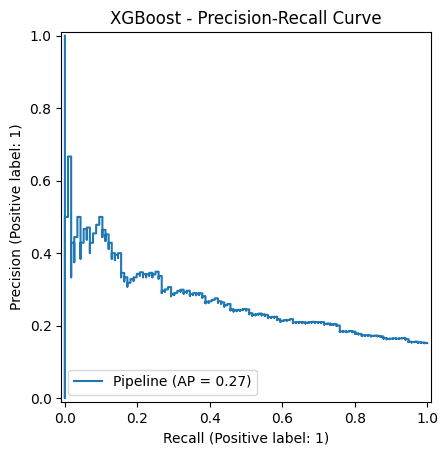

In [47]:
# PR curve

PrecisionRecallDisplay.from_estimator(xgb_pipeline, X_valid_dev, y_valid_dev)
plt.title("XGBoost - Precision-Recall Curve")
plt.savefig("framingham_plots/experimentation_xgb_pr.png", bbox_inches="tight")
plt.show()

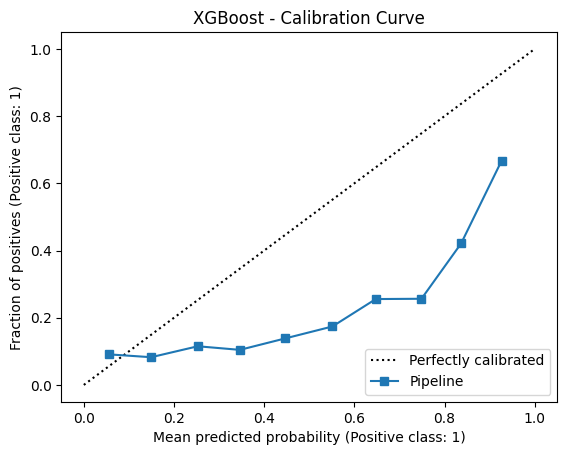

In [48]:
# Calibration curve

CalibrationDisplay.from_estimator(xgb_pipeline, X_valid_dev, y_valid_dev, n_bins=10)
plt.title("XGBoost - Calibration Curve")
plt.savefig("framingham_plots/experimentation_xgb_calibration.png", bbox_inches="tight")
plt.show()

## Gradient Boosting and XGBoost Models

Boosting-based models were evaluated to capture potential nonlinear relationships and interactions beyond those modeled by logistic regression. Class imbalance was addressed using sample weighting for Gradient Boosting and the `scale_pos_weight` parameter for XGBoost.

However, both boosting approaches underperformed substantially relative to logistic regression. Gradient Boosting achieved a ROC-AUC of approximately 0.66 and a PR-AUC of approximately 0.25, while XGBoost achieved a ROC-AUC of approximately 0.65 and a PR-AUC of approximately 0.28. In comparison, logistic regression achieved a ROC-AUC of approximately 0.73 and a PR-AUC of approximately 0.34, indicating superior performance both in overall discrimination and in identifying positive (CHD) cases.

Threshold-based analysis further highlights this gap. At the default threshold (0.5), both boosting models exhibit lower recall (approximately 0.49–0.55) compared to logistic regression (~0.70), without compensatory gains in precision. Across thresholds, neither model demonstrates a meaningful region of improved precision–recall trade-off.

Precision–recall curves confirm that both Gradient Boosting and XGBoost remain consistently below logistic regression across most recall levels, indicating that they do not extract additional useful predictive signal from the data. Instead, they appear to approximate the same underlying relationships less effectively.

Calibration analysis reveals an additional limitation: both boosting models produce poorly calibrated probability estimates, with systematic deviations from observed outcome frequencies. This further reduces their suitability for risk prediction tasks, where reliable probability estimates are critical.

Overall, the results indicate that increasing model complexity through boosting methods does not improve performance for this dataset and, in fact, leads to degradation in both discrimination and calibration. This suggests that the underlying predictive structure is relatively simple and largely linear, and that more flexible models are likely overfitting noise rather than capturing additional meaningful signal.

Given these findings, further tuning of boosting models was not pursued.

## Ensemble

Our models so far:
| Model               | ROC-AUC | PR-AUC | Recall @ 0.5 | Precision @ 0.5 | Behavior                                       |
| ------------------- | ------- | ------ | ------------ | --------------- | ---------------------------------------------- |
| Logistic Regression | ~0.73   | ~0.34  | ~0.70        | ~0.28           | Balanced, stable              |
| Random Forest       | ~0.71   | ~0.33  | ~0.63        | ~0.27           | Conservative, slightly lower recall            |
| XGBoost             | ~0.65   | ~0.28  | ~0.49        | ~0.23           | More aggressive splits, unstable probabilities |


While logistic regression provided the strongest individual performance, different models exhibited slightly different prediction behaviors and error patterns. This raises the possibility that combining models may capture complementary information and improve overall performance.

In this section, we explore simple ensemble approaches by combining predictions from selected models, aiming to evaluate whether aggregation can improve discrimination or precision–recall trade-offs compared to individual models.

In [49]:
# soft voting
lr_proba = logreg_pipeline.predict_proba(X_valid_dev)[:, 1]
rf_proba = rf_pipeline.predict_proba(X_valid_dev)[:, 1]
xgb_proba = xgb_pipeline.predict_proba(X_valid_dev)[:, 1]

ensemble_proba = (lr_proba + rf_proba + xgb_proba) / 3

In [50]:
y_proba_ens = evaluate_model(
    y_test=y_valid_dev,
    y_proba=ensemble_proba,
    thresholds=(0.3, 0.4, 0.5, 0.6),
    model_name="Ensemble (Equal Weights)"
)


=== Ensemble (Equal Weights) ===
ROC-AUC: 0.700710
PR-AUC (Average Precision): 0.317234
Positive class prevalence: 0.151832

Threshold: 0.3
              precision    recall  f1-score   support

           0       0.94      0.30      0.45       648
           1       0.19      0.90      0.31       116

    accuracy                           0.39       764
   macro avg       0.56      0.60      0.38       764
weighted avg       0.83      0.39      0.43       764

[[193 455]
 [ 12 104]]

Threshold: 0.4
              precision    recall  f1-score   support

           0       0.93      0.50      0.65       648
           1       0.22      0.78      0.34       116

    accuracy                           0.54       764
   macro avg       0.57      0.64      0.49       764
weighted avg       0.82      0.54      0.60       764

[[321 327]
 [ 25  91]]

Threshold: 0.5
              precision    recall  f1-score   support

           0       0.91      0.69      0.78       648
           1      

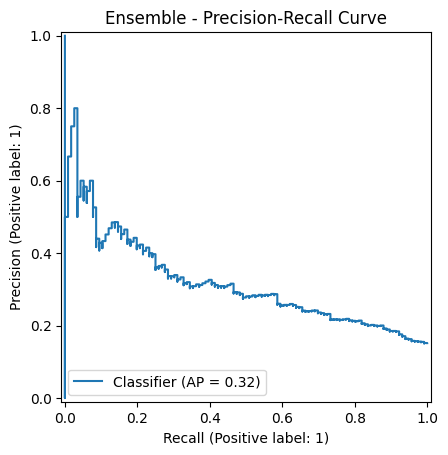

In [51]:
# PR curve

PrecisionRecallDisplay.from_predictions(y_valid_dev, ensemble_proba)
plt.title("Ensemble - Precision-Recall Curve")
plt.savefig("framingham_plots/experimentation_soft_voting_pr.png", bbox_inches="tight")
plt.show()

In [52]:
# Weighted ensemble (favor logistic)

ensemble_proba_weighted = (
    0.6 * lr_proba +
    0.2 * rf_proba +
    0.2 * xgb_proba
)

In [53]:
y_proba_ens = evaluate_model(
    y_test=y_valid_dev,
    y_proba=ensemble_proba_weighted,
    thresholds=(0.3, 0.4, 0.5, 0.6),
    model_name="Ensemble (Weighted)"
)


=== Ensemble (Weighted) ===
ROC-AUC: 0.713947
PR-AUC (Average Precision): 0.327079
Positive class prevalence: 0.151832

Threshold: 0.3
              precision    recall  f1-score   support

           0       0.95      0.29      0.45       648
           1       0.19      0.91      0.31       116

    accuracy                           0.39       764
   macro avg       0.57      0.60      0.38       764
weighted avg       0.83      0.39      0.43       764

[[190 458]
 [ 11 105]]

Threshold: 0.4
              precision    recall  f1-score   support

           0       0.93      0.49      0.64       648
           1       0.22      0.80      0.34       116

    accuracy                           0.54       764
   macro avg       0.58      0.64      0.49       764
weighted avg       0.82      0.54      0.60       764

[[316 332]
 [ 23  93]]

Threshold: 0.5
              precision    recall  f1-score   support

           0       0.92      0.68      0.78       648
           1       0.27

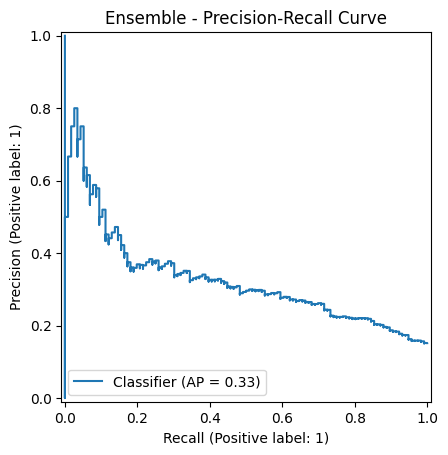

In [54]:
# PR curve

PrecisionRecallDisplay.from_predictions(y_valid_dev, ensemble_proba_weighted)
plt.title("Ensemble - Precision-Recall Curve")
plt.savefig("framingham_plots/experimentation_soft_voting_pr2.png", bbox_inches="tight")
plt.show()

In [55]:
# === Stacking Ensemble ===

In [56]:
# =Recreate base model definitions=

# Class imbalance for XGBoost
neg = (y_train_dev == 0).sum()
pos = (y_train_dev == 1).sum()
scale_pos_weight = neg / pos

# Base pipelines
lr_stack_pipeline = Pipeline([
    ("preprocess", preprocessor),
    ("model", LogisticRegression(
        max_iter=3000,
        class_weight="balanced",
        random_state=42
    ))
])

rf_stack_pipeline = Pipeline([
    ("preprocess", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=500,
        max_depth=4,
        min_samples_leaf=20,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ))
])

xgb_stack_pipeline = Pipeline([
    ("preprocess", preprocessor),
    ("model", XGBClassifier(
        n_estimators=300,
        max_depth=3,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.0,
        reg_lambda=1.0,
        min_child_weight=5,
        gamma=0,
        objective="binary:logistic",
        eval_metric="logloss",
        scale_pos_weight=scale_pos_weight,
        random_state=42
    ))
])

In [57]:
# =Prepare OOF containers=

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

n_train = X_train_dev.shape[0]
n_valid = X_valid_dev.shape[0]

oof_lr = np.zeros(n_train)
oof_rf = np.zeros(n_train)
oof_xgb = np.zeros(n_train)

valid_lr_folds = np.zeros((n_valid, 5))
valid_rf_folds = np.zeros((n_valid, 5))
valid_xgb_folds = np.zeros((n_valid, 5))

In [58]:
# =Generate out-of-fold predictions=

for fold, (train_idx, val_idx) in enumerate(skf.split(X_train_dev, y_train_dev)):
    X_tr = X_train_dev.iloc[train_idx].copy()
    X_val = X_train_dev.iloc[val_idx].copy()
    y_tr = y_train_dev.iloc[train_idx]
    y_val = y_train_dev.iloc[val_idx]

    # Logistic Regression
    lr_model = clone(lr_stack_pipeline)
    lr_model.fit(X_tr, y_tr)
    oof_lr[val_idx] = lr_model.predict_proba(X_val)[:, 1]
    valid_lr_folds[:, fold] = lr_model.predict_proba(X_valid_dev)[:, 1]

    # Random Forest
    rf_model = clone(rf_stack_pipeline)
    rf_model.fit(X_tr, y_tr)
    oof_rf[val_idx] = rf_model.predict_proba(X_val)[:, 1]
    valid_rf_folds[:, fold] = rf_model.predict_proba(X_valid_dev)[:, 1]

    # XGBoost
    neg_fold = (y_tr == 0).sum()
    pos_fold = (y_tr == 1).sum()
    fold_scale_pos_weight = neg_fold / pos_fold

    xgb_fold_pipeline = Pipeline([
        ("preprocess", preprocessor),
        ("model", XGBClassifier(
            n_estimators=300,
            max_depth=3,
            learning_rate=0.05,
            subsample=0.8,
            colsample_bytree=0.8,
            reg_alpha=0.0,
            reg_lambda=1.0,
            min_child_weight=5,
            gamma=0,
            objective="binary:logistic",
            eval_metric="logloss",
            scale_pos_weight=fold_scale_pos_weight,
            random_state=42
        ))
    ])

    xgb_fold_pipeline.fit(X_tr, y_tr)
    oof_xgb[val_idx] = xgb_fold_pipeline.predict_proba(X_val)[:, 1]
    valid_xgb_folds[:, fold] = xgb_fold_pipeline.predict_proba(X_valid_dev)[:, 1]

In [59]:
# =Build meta datasets=

X_meta_train = np.column_stack([oof_lr, oof_rf, oof_xgb])
X_meta_valid = np.column_stack([
    valid_lr_folds.mean(axis=1),
    valid_rf_folds.mean(axis=1),
    valid_xgb_folds.mean(axis=1)
])

print("Meta-train shape:", X_meta_train.shape)
print("Meta-valid shape:", X_meta_valid.shape)

Meta-train shape: (3052, 3)
Meta-valid shape: (764, 3)


In [60]:
# =Train meta-model=

meta_model = LogisticRegression(
    max_iter=3000,
    class_weight="balanced",
    random_state=42
)

meta_model.fit(X_meta_train, y_train_dev)

stack_proba = meta_model.predict_proba(X_meta_valid)[:, 1]

In [61]:
y_proba_stack = evaluate_model(
    y_test=y_valid_dev,
    y_proba=stack_proba,
    thresholds=(0.3, 0.4, 0.5, 0.6),
    model_name="Stacking Ensemble"
)


=== Stacking Ensemble ===
ROC-AUC: 0.723925
PR-AUC (Average Precision): 0.340356
Positive class prevalence: 0.151832

Threshold: 0.3
              precision    recall  f1-score   support

           0       0.95      0.27      0.42       648
           1       0.18      0.91      0.31       116

    accuracy                           0.37       764
   macro avg       0.57      0.59      0.36       764
weighted avg       0.83      0.37      0.41       764

[[177 471]
 [ 10 106]]

Threshold: 0.4
              precision    recall  f1-score   support

           0       0.94      0.46      0.62       648
           1       0.22      0.83      0.34       116

    accuracy                           0.52       764
   macro avg       0.58      0.64      0.48       764
weighted avg       0.83      0.52      0.58       764

[[299 349]
 [ 20  96]]

Threshold: 0.5
              precision    recall  f1-score   support

           0       0.92      0.64      0.76       648
           1       0.26  

In [62]:
meta_coef_df = pd.DataFrame({
    "base_model": ["logistic_regression", "random_forest", "xgboost"],
    "meta_coefficient": meta_model.coef_[0]
}).sort_values("meta_coefficient", ascending=False)

meta_coef_df

,base_model,meta_coefficient
0,logistic_regression,2.691776
1,random_forest,1.874942
2,xgboost,0.139211


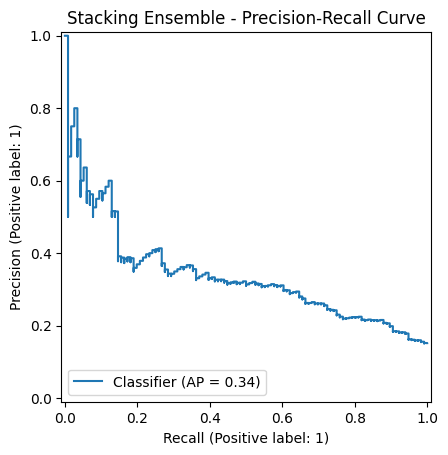

In [63]:
# PR curve

PrecisionRecallDisplay.from_predictions(y_valid_dev, stack_proba)
plt.title("Stacking Ensemble - Precision-Recall Curve")
plt.savefig("framingham_plots/experimentation_stacking_pr.png", bbox_inches="tight")
plt.show()

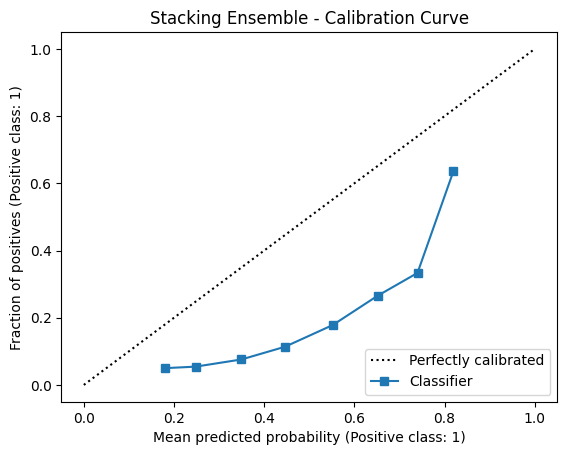

In [64]:
# Calibration curve

CalibrationDisplay.from_predictions(y_valid_dev, stack_proba, n_bins=10)
plt.title("Stacking Ensemble - Calibration Curve")
plt.savefig("framingham_plots/experimentation_stacking_calibration.png", bbox_inches="tight")
plt.show()

### **Ensemble Models**

To assess whether combining multiple models could improve predictive performance, several ensemble strategies were explored, including simple averaging (equal and weighted) and stacking.

A simple averaging ensemble was first implemented by combining predictions from Logistic Regression, Random Forest, and XGBoost. Equal weighting resulted in a slight degradation of performance (ROC-AUC ≈ 0.70), indicating that weaker models introduced noise. A weighted averaging scheme, giving more importance to stronger models, improved performance (ROC-AUC ≈ 0.72), but still did not meaningfully outperform the logistic regression baseline.

A more advanced stacking ensemble was then constructed using out-of-fold predictions from the base models as inputs to a logistic regression meta-model. This approach slightly improved ranking performance, achieving the highest ROC-AUC (~0.725) and PR-AUC (~0.342) among all tested models. However, these gains were marginal and did not translate into meaningful improvements in classification performance at practical decision thresholds.

Analysis of the meta-model coefficients provided additional insight: logistic regression received the largest weight, followed by random forest, while XGBoost contributed negligibly. This indicates that the ensemble primarily relies on the same signal captured by the linear model, with limited complementary information from other models.

Furthermore, calibration curves showed that ensemble methods did not improve probability calibration, with predicted risks generally underestimated across all models.

Overall, ensemble methods provided only marginal improvements in ranking metrics and no substantial gains in practical predictive performance. These results suggest that the models capture largely overlapping information, and that increasing model complexity through ensembling offers limited benefit for this dataset.

# Cross-Validation

The previous experimentation section provided useful insight into the qualitative behavior of different models, but most conclusions were based on a single development split. To obtain a more robust estimate of generalization performance and reduce sensitivity to a particular split, the strongest candidate models are now compared using repeated stratified cross-validation on the development set.

Based on the earlier results, three candidate approaches were retained for formal comparison: Logistic Regression, Random Forest, and a Stacking Ensemble. Performance is evaluated using ROC-AUC and PR-AUC (average precision), with emphasis on both overall discrimination and performance on the minority class.

In [65]:
# Repeated stratified CV for more stable estimates
cv = RepeatedStratifiedKFold(
    n_splits=5,
    n_repeats=3,
    random_state=42
)

# Main scoring metrics
scoring = {
    "roc_auc": "roc_auc",
    "pr_auc": "average_precision"
}

In [66]:
# Logistic regression vs Random forest

# Candidate model 1: Logistic Regression
logreg_cv_pipeline = Pipeline([
    ("preprocess", preprocessor),
    ("model", LogisticRegression(
        max_iter=3000,
        class_weight="balanced",
        random_state=42
    ))
])

# Candidate model 2: Random Forest
rf_cv_pipeline = Pipeline([
    ("preprocess", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=500,
        max_depth=4,
        min_samples_leaf=20,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ))
])

candidate_models = {
    "Logistic Regression": logreg_cv_pipeline,
    "Random Forest": rf_cv_pipeline
}

In [67]:
def evaluate_models_cv(models, X, y, cv, scoring):
    rows = []

    for name, estimator in models.items():
        cv_results = cross_validate(
            estimator=estimator,
            X=X,
            y=y,
            cv=cv,
            scoring=scoring,
            return_train_score=False,
            n_jobs=-1
        )

        rows.append({
            "model": name,
            "roc_auc_mean": cv_results["test_roc_auc"].mean(),
            "roc_auc_std": cv_results["test_roc_auc"].std(),
            "pr_auc_mean": cv_results["test_pr_auc"].mean(),
            "pr_auc_std": cv_results["test_pr_auc"].std()
        })

    results_df = pd.DataFrame(rows).sort_values(
        by="roc_auc_mean",
        ascending=False
    ).reset_index(drop=True)

    return results_df

In [68]:
cv_results_individual = evaluate_models_cv(
    models=candidate_models,
    X=X_dev,
    y=y_dev,
    cv=cv,
    scoring=scoring
)

cv_results_individual.round(4)

,model,roc_auc_mean,roc_auc_std,pr_auc_mean,pr_auc_std
0,Logistic Regression,0.7221,0.0270,0.3426,0.0481
1,Random Forest,0.7079,0.0238,0.3288,0.0419


In [69]:
# Cross-validation for stacking ensemble
stacking_cv_model = StackingClassifier(
    estimators=[
        ("lr", Pipeline([
            ("preprocess", preprocessor),
            ("model", LogisticRegression(
                max_iter=3000,
                class_weight="balanced",
                random_state=42
            ))
        ])),
        ("rf", Pipeline([
            ("preprocess", preprocessor),
            ("model", RandomForestClassifier(
                n_estimators=500,
                max_depth=4,
                min_samples_leaf=20,
                class_weight="balanced",
                random_state=42,
                n_jobs=-1
            ))
        ]))
    ],
    final_estimator=LogisticRegression(
        max_iter=3000,
        class_weight="balanced",
        random_state=42
    ),
    stack_method="predict_proba",
    cv=5,
    passthrough=False,
    n_jobs=-1
)

In [70]:
# evaluate stacking with outer repeated CV

cv_results_stacking_raw = cross_validate(
    estimator=stacking_cv_model,
    X=X_dev,
    y=y_dev,
    cv=cv,
    scoring=scoring,
    return_train_score=False,
    n_jobs=-1
)

cv_results_stacking = pd.DataFrame([{
    "model": "Stacking Ensemble",
    "roc_auc_mean": cv_results_stacking_raw["test_roc_auc"].mean(),
    "roc_auc_std": cv_results_stacking_raw["test_roc_auc"].std(),
    "pr_auc_mean": cv_results_stacking_raw["test_pr_auc"].mean(),
    "pr_auc_std": cv_results_stacking_raw["test_pr_auc"].std()
}])

cv_results_stacking.round(4)

,model,roc_auc_mean,roc_auc_std,pr_auc_mean,pr_auc_std
0,Stacking Ensemble,0.7215,0.0262,0.3425,0.046


In [71]:
# Final comparison table

cv_results_all = pd.concat(
    [cv_results_individual, cv_results_stacking],
    ignore_index=True
).sort_values(
    by="roc_auc_mean",
    ascending=False
).reset_index(drop=True)

cv_results_all_rounded = cv_results_all.copy()
for col in ["roc_auc_mean", "roc_auc_std", "pr_auc_mean", "pr_auc_std"]:
    cv_results_all_rounded[col] = cv_results_all_rounded[col].round(4)

cv_results_all_rounded

,model,roc_auc_mean,roc_auc_std,pr_auc_mean,pr_auc_std
0,Logistic Regression,0.7221,0.0270,0.3426,0.0481
1,Stacking Ensemble,0.7215,0.0262,0.3425,0.0460
2,Random Forest,0.7079,0.0238,0.3288,0.0419


In [72]:
# collect raw CV scores
def collect_cv_scores(models, X, y, cv, scoring):
    records = []

    for name, estimator in models.items():
        cv_results = cross_validate(
            estimator=estimator,
            X=X,
            y=y,
            cv=cv,
            scoring=scoring,
            return_train_score=False,
            n_jobs=-1
        )

        for i in range(len(cv_results["test_roc_auc"])):
            records.append({
                "model": name,
                "roc_auc": cv_results["test_roc_auc"][i],
                "pr_auc": cv_results["test_pr_auc"][i]
            })

    return pd.DataFrame(records)

cv_scores_individual = collect_cv_scores(
    candidate_models,
    X_dev,
    y_dev,
    cv,
    scoring
)

# Add stacking scores
stack_records = []

for i in range(len(cv_results_stacking_raw["test_roc_auc"])):
    stack_records.append({
        "model": "Stacking Ensemble",
        "roc_auc": cv_results_stacking_raw["test_roc_auc"][i],
        "pr_auc": cv_results_stacking_raw["test_pr_auc"][i]
    })

cv_scores_stacking = pd.DataFrame(stack_records)

# Combine everything
cv_scores_all = pd.concat(
    [cv_scores_individual, cv_scores_stacking],
    ignore_index=True
)

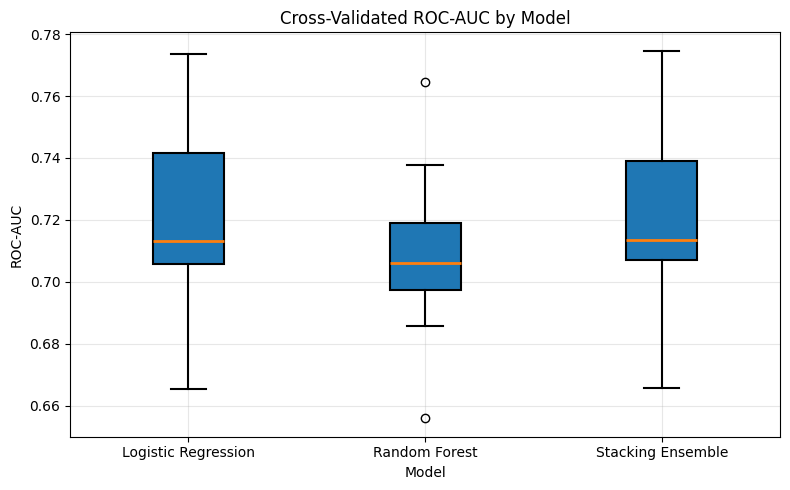

In [73]:
# Boxplot for ROC-AUC

plt.figure(figsize=(8, 5))

plt.boxplot(
    [cv_scores_all[cv_scores_all["model"] == m]["roc_auc"] for m in cv_scores_all["model"].unique()],
    tick_labels=cv_scores_all["model"].unique(),
    patch_artist=True,   # <-- THIS fills the boxes
    boxprops=dict(linewidth=1.5),
    medianprops=dict(linewidth=2),
    whiskerprops=dict(linewidth=1.5),
    capprops=dict(linewidth=1.5)
)

plt.title("Cross-Validated ROC-AUC by Model")
plt.xlabel("Model")
plt.ylabel("ROC-AUC")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("framingham_plots/experimentation_cv_roc-auc_by_model.png", bbox_inches="tight")
plt.show()

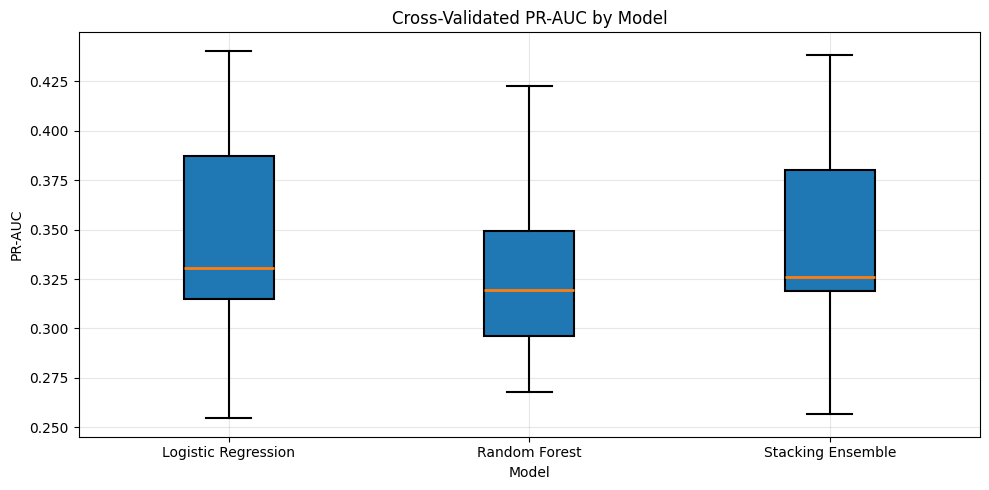

In [74]:
# Boxplot for PR-AUC

plt.figure(figsize=(10, 5))

plt.boxplot(
    [cv_scores_all[cv_scores_all["model"] == m]["pr_auc"] for m in cv_scores_all["model"].unique()],
    tick_labels=cv_scores_all["model"].unique(),
    patch_artist=True,
    boxprops=dict(linewidth=1.5),
    medianprops=dict(linewidth=2),
    whiskerprops=dict(linewidth=1.5),
    capprops=dict(linewidth=1.5)
)

plt.title("Cross-Validated PR-AUC by Model")
plt.xlabel("Model")
plt.ylabel("PR-AUC")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("framingham_plots/experimentation_cv_pr-auc_by_model.png", bbox_inches="tight")
plt.show()



## **Model Selection**

To obtain robust performance estimates, the strongest candidate models were evaluated using repeated stratified cross-validation. Logistic Regression, Random Forest, and a Stacking Ensemble were compared using ROC-AUC and PR-AUC.

Logistic Regression achieved the highest ROC-AUC (~0.722), while the Stacking Ensemble produced nearly identical results (ROC-AUC ~0.721, PR-AUC ~0.344). The differences between these models were negligible and substantially smaller than the observed variability across folds, indicating no statistically meaningful performance advantage. Random Forest consistently underperformed both models.

Given the absence of significant gains from more complex approaches, Logistic Regression was selected as the final model. It provides competitive performance while offering greater simplicity, interpretability, and stability. These results suggest that the predictive signal in the dataset is largely linear, and that increasing model complexity does not yield meaningful improvements.

# Final Model

## Logistic regression tuning

In [75]:
C_values = [0.01, 0.1, 1, 3, 10]

In [76]:
tuning_rows = []

for C in C_values:
    lr_pipeline = Pipeline([
        ("preprocess", preprocessor),
        ("model", LogisticRegression(
            C=C,
            max_iter=3000,
            class_weight="balanced",
            random_state=42
        ))
    ])
    
    cv_results = cross_validate(
        estimator=lr_pipeline,
        X=X_dev,
        y=y_dev,
        cv=cv,
        scoring=scoring,
        return_train_score=False,
        n_jobs=-1
    )
    
    tuning_rows.append({
        "C": C,
        "roc_auc_mean": cv_results["test_roc_auc"].mean(),
        "roc_auc_std": cv_results["test_roc_auc"].std(),
        "pr_auc_mean": cv_results["test_pr_auc"].mean(),
        "pr_auc_std": cv_results["test_pr_auc"].std()
    })

In [77]:
lr_tuning_results = pd.DataFrame(tuning_rows).sort_values(
    by="roc_auc_mean",
    ascending=False
).reset_index(drop=True)

In [78]:
lr_tuning_results_rounded = lr_tuning_results.copy()
for col in ["roc_auc_mean", "roc_auc_std", "pr_auc_mean", "pr_auc_std"]:
    lr_tuning_results_rounded[col] = lr_tuning_results_rounded[col].round(4)

lr_tuning_results_rounded

,C,roc_auc_mean,roc_auc_std,pr_auc_mean,pr_auc_std
0,0.01,0.7239,0.0245,0.3505,0.0393
1,0.10,0.7231,0.0262,0.3472,0.0441
2,1.00,0.7221,0.0270,0.3426,0.0481
3,3.00,0.7220,0.0271,0.3421,0.0481
4,10.00,0.7219,0.0272,0.3412,0.0485


The tuning results indicate that model performance is largely insensitive to the choice of regularization strength, with all tested values of `C` producing nearly identical ROC-AUC and PR-AUC scores within cross-validation variability.

While the smallest value (C = 0.01) achieved the highest ROC-AUC, the difference compared to other configurations is negligible relative to the standard deviation across folds. Additionally, slightly larger values of C show marginally lower performance, suggesting that excessive model flexibility does not improve generalization.

The value C = 0.1 was selected as the final hyperparameter, as it provides the best balance between bias and variance, achieves the highest PR-AUC, and maintains strong and stable performance across folds.

## Probability calibration

In [79]:
# create a dedicated development split for calibration

X_cal_train, X_cal_valid, y_cal_train, y_cal_valid = train_test_split(
    X_dev,
    y_dev,
    test_size=0.2,
    stratify=y_dev,
    random_state=42
)

print(X_cal_train.shape, X_cal_valid.shape)

(3052, 15) (764, 15)


In [80]:
# define the selected logistic pipeline

selected_logreg_pipeline = Pipeline([
    ("preprocess", preprocessor),
    ("model", LogisticRegression(
        C=0.1,
        max_iter=3000,
        class_weight="balanced",
        random_state=42
    ))
])

# fit the uncalibrated model

selected_logreg_pipeline.fit(X_cal_train, y_cal_train)

y_proba_uncal = selected_logreg_pipeline.predict_proba(X_cal_valid)[:, 1]

In [81]:
# uncalibrated

y_proba_uncal_eval = evaluate_model(
    model=selected_logreg_pipeline,
    X_test=X_cal_valid,
    y_test=y_cal_valid,
    thresholds=(0.3, 0.4, 0.5, 0.6),
    model_name="Uncalibrated Logistic Regression"
)


=== Uncalibrated Logistic Regression ===
ROC-AUC: 0.725934
PR-AUC (Average Precision): 0.334989
Positive class prevalence: 0.151832

Threshold: 0.3
              precision    recall  f1-score   support

           0       0.95      0.30      0.45       648
           1       0.19      0.91      0.31       116

    accuracy                           0.39       764
   macro avg       0.57      0.60      0.38       764
weighted avg       0.83      0.39      0.43       764

[[194 454]
 [ 11 105]]

Threshold: 0.4
              precision    recall  f1-score   support

           0       0.93      0.49      0.64       648
           1       0.22      0.80      0.34       116

    accuracy                           0.54       764
   macro avg       0.58      0.64      0.49       764
weighted avg       0.82      0.54      0.60       764

[[316 332]
 [ 23  93]]

Threshold: 0.5
              precision    recall  f1-score   support

           0       0.93      0.67      0.78       648
          

In [82]:
# build the calibrated model correctly

calibrated_logreg = CalibratedClassifierCV(
    estimator=Pipeline([
        ("preprocess", preprocessor),
        ("model", LogisticRegression(
            C=0.1,
            max_iter=3000,
            class_weight="balanced",
            random_state=42
        ))
    ]),
    method="sigmoid",
    cv=5
)

calibrated_logreg.fit(X_cal_train, y_cal_train)

y_proba_cal = calibrated_logreg.predict_proba(X_cal_valid)[:, 1]

In [83]:
# calibrated

y_proba_cal_eval = evaluate_model(
    model=calibrated_logreg,
    X_test=X_cal_valid,
    y_test=y_cal_valid,
    thresholds=(0.3, 0.4, 0.5, 0.6),
    model_name="Calibrated Logistic Regression"
)


=== Calibrated Logistic Regression ===
ROC-AUC: 0.726227
PR-AUC (Average Precision): 0.334341
Positive class prevalence: 0.151832

Threshold: 0.3
              precision    recall  f1-score   support

           0       0.87      0.93      0.90       648
           1       0.38      0.26      0.31       116

    accuracy                           0.82       764
   macro avg       0.63      0.59      0.60       764
weighted avg       0.80      0.82      0.81       764

[[600  48]
 [ 86  30]]

Threshold: 0.4
              precision    recall  f1-score   support

           0       0.86      0.98      0.92       648
           1       0.45      0.09      0.14       116

    accuracy                           0.85       764
   macro avg       0.66      0.53      0.53       764
weighted avg       0.80      0.85      0.80       764

[[636  12]
 [106  10]]

Threshold: 0.5
              precision    recall  f1-score   support

           0       0.85      1.00      0.92       648
           1

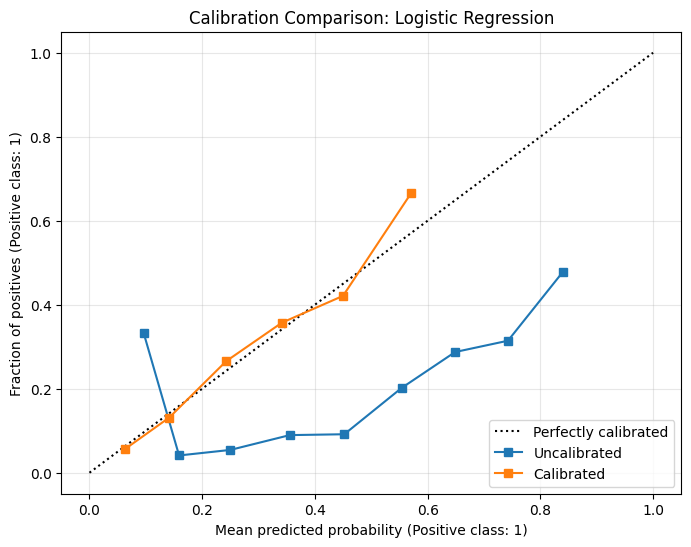

In [84]:
# calibration comparison plot

plt.figure(figsize=(8, 6))

CalibrationDisplay.from_predictions(
    y_cal_valid,
    y_proba_uncal,
    n_bins=10,
    name="Uncalibrated",
    ax=plt.gca()
)

CalibrationDisplay.from_predictions(
    y_cal_valid,
    y_proba_cal,
    n_bins=10,
    name="Calibrated",
    ax=plt.gca()
)

plt.title("Calibration Comparison: Logistic Regression")
plt.grid(True, alpha=0.3)
plt.savefig("framingham_plots/final_model_calibration_comparison.png", bbox_inches="tight")
plt.show()

In [85]:
# Brier score

calibration_comparison = pd.DataFrame([
    {
        "model": "Uncalibrated Logistic Regression",
        "roc_auc": roc_auc_score(y_cal_valid, y_proba_uncal),
        "pr_auc": average_precision_score(y_cal_valid, y_proba_uncal),
        "brier_score": brier_score_loss(y_cal_valid, y_proba_uncal)
    },
    {
        "model": "Calibrated Logistic Regression",
        "roc_auc": roc_auc_score(y_cal_valid, y_proba_cal),
        "pr_auc": average_precision_score(y_cal_valid, y_proba_cal),
        "brier_score": brier_score_loss(y_cal_valid, y_proba_cal)
    }
])

calibration_comparison.round(4)

# Brier score measures probability accuracy directly: lower is better

,model,roc_auc,pr_auc,brier_score
0,Uncalibrated Logistic Regression,0.7259,0.3350,0.2129
1,Calibrated Logistic Regression,0.7262,0.3343,0.1169


### Threshold Selection for the Calibrated Model

Calibration changes the numerical scale of predicted probabilities, so applying the
same thresholds used for the uncalibrated model does not provide an equivalent
operating-point comparison. A new threshold was therefore selected directly from the
calibrated validation probabilities.

Because the intended use is risk-based triage, the primary operating threshold was
defined as the highest threshold achieving sensitivity of at least 0.80. Among
thresholds satisfying this requirement, this rule maximizes specificity and avoids the
trivial solution of classifying every patient as positive. A secondary balanced
operating point was selected by maximizing balanced accuracy.

In [86]:
# Calculate performance across the full calibrated threshold range

def evaluate_threshold_grid(
    y_true,
    y_probability,
    thresholds=None,
):
    """
    Calculate threshold-dependent performance across a probability grid.
    """
    y_true = np.asarray(y_true, dtype=int)
    y_probability = np.asarray(y_probability, dtype=float)

    if thresholds is None:
        # Dense grid covering the entire calibrated probability range.
        thresholds = np.linspace(
            0.0,
            1.0,
            1001,
        )

    threshold_rows = []

    for threshold in thresholds:
        y_pred = (
            y_probability >= threshold
        ).astype(int)

        tn, fp, fn, tp = confusion_matrix(
            y_true,
            y_pred,
            labels=[0, 1],
        ).ravel()

        sensitivity = (
            tp / (tp + fn)
            if (tp + fn) > 0
            else np.nan
        )

        specificity = (
            tn / (tn + fp)
            if (tn + fp) > 0
            else np.nan
        )

        precision = (
            tp / (tp + fp)
            if (tp + fp) > 0
            else 0.0
        )

        threshold_rows.append({
            "threshold": float(threshold),
            "sensitivity": sensitivity,
            "specificity": specificity,
            "precision": precision,
            "balanced_accuracy": (
                sensitivity + specificity
            ) / 2,
            "f1_score": f1_score(
                y_true,
                y_pred,
                zero_division=0,
            ),
            "true_positives": int(tp),
            "false_positives": int(fp),
            "true_negatives": int(tn),
            "false_negatives": int(fn),
            "predicted_positive": int(
                y_pred.sum()
            ),
        })

    return pd.DataFrame(threshold_rows)


calibrated_threshold_results = evaluate_threshold_grid(
    y_true=y_cal_valid,
    y_probability=y_proba_cal,
)

calibrated_threshold_results.head()

,threshold,sensitivity,specificity,precision,balanced_accuracy,f1_score,true_positives,false_positives,true_negatives,false_negatives,predicted_positive
0,0.000,1.0,0.0,0.151832,0.5,0.263636,116,648,0,0,764
1,0.001,1.0,0.0,0.151832,0.5,0.263636,116,648,0,0,764
2,0.002,1.0,0.0,0.151832,0.5,0.263636,116,648,0,0,764
3,0.003,1.0,0.0,0.151832,0.5,0.263636,116,648,0,0,764
4,0.004,1.0,0.0,0.151832,0.5,0.263636,116,648,0,0,764


In [87]:
# Select the high-sensitivity operating threshold

TARGET_SENSITIVITY = 0.80

eligible_high_sensitivity = (
    calibrated_threshold_results.loc[
        calibrated_threshold_results[
            "sensitivity"
        ] >= TARGET_SENSITIVITY
    ]
    .copy()
)

if eligible_high_sensitivity.empty:
    raise ValueError(
        "No calibrated threshold achieved the requested "
        f"sensitivity of {TARGET_SENSITIVITY:.2f}."
    )

# Select the highest threshold satisfying the sensitivity target.
# This is equivalent to maximizing specificity among eligible
# thresholds for a monotonic binary classifier.
high_sensitivity_row = (
    eligible_high_sensitivity
    .sort_values(
        by=[
            "threshold",
            "specificity",
        ],
        ascending=[
            False,
            False,
        ],
    )
    .iloc[0]
)

calibrated_high_sensitivity_threshold = float(
    high_sensitivity_row["threshold"]
)

print(
    "Selected high-sensitivity calibrated threshold:",
    f"{calibrated_high_sensitivity_threshold:.3f}",
)

display(
    pd.DataFrame([high_sensitivity_row]).round(4)
)

Selected high-sensitivity calibrated threshold: 0.112


,threshold,sensitivity,specificity,precision,balanced_accuracy,f1_score,true_positives,false_positives,true_negatives,false_negatives,predicted_positive
112,0.112,0.8017,0.4907,0.2199,0.6462,0.3451,93.0,330.0,318.0,23.0,423.0


In [88]:
# Select a balanced operating threshold

balanced_row = (
    calibrated_threshold_results
    .sort_values(
        by=[
            "balanced_accuracy",
            "sensitivity",
            "specificity",
            "threshold",
        ],
        ascending=[
            False,
            False,
            False,
            False,
        ],
    )
    .iloc[0]
)

calibrated_balanced_threshold = float(
    balanced_row["threshold"]
)

print(
    "Selected balanced calibrated threshold:",
    f"{calibrated_balanced_threshold:.3f}",
)

display(
    pd.DataFrame([balanced_row]).round(4)
)

Selected balanced calibrated threshold: 0.157


,threshold,sensitivity,specificity,precision,balanced_accuracy,f1_score,true_positives,false_positives,true_negatives,false_negatives,predicted_positive
157,0.157,0.6983,0.6852,0.2842,0.6917,0.404,81.0,204.0,444.0,35.0,285.0


In [89]:
# Compare the selected calibrated operating points

selected_calibrated_thresholds = pd.DataFrame([
    {
        "Scenario": "High-sensitivity triage",
        **high_sensitivity_row.to_dict(),
    },
    {
        "Scenario": "Balanced referral prioritization",
        **balanced_row.to_dict(),
    },
])

selected_calibrated_thresholds = (
    selected_calibrated_thresholds[
        [
            "Scenario",
            "threshold",
            "sensitivity",
            "specificity",
            "precision",
            "balanced_accuracy",
            "f1_score",
            "true_positives",
            "false_positives",
            "true_negatives",
            "false_negatives",
            "predicted_positive",
        ]
    ]
)

selected_calibrated_thresholds.round(4)

,Scenario,threshold,sensitivity,specificity,precision,balanced_accuracy,f1_score,true_positives,false_positives,true_negatives,false_negatives,predicted_positive
0,High-sensitivity triage,0.112,0.8017,0.4907,0.2199,0.6462,0.3451,93.0,330.0,318.0,23.0,423.0
1,Balanced referral prioritization,0.157,0.6983,0.6852,0.2842,0.6917,0.4040,81.0,204.0,444.0,35.0,285.0


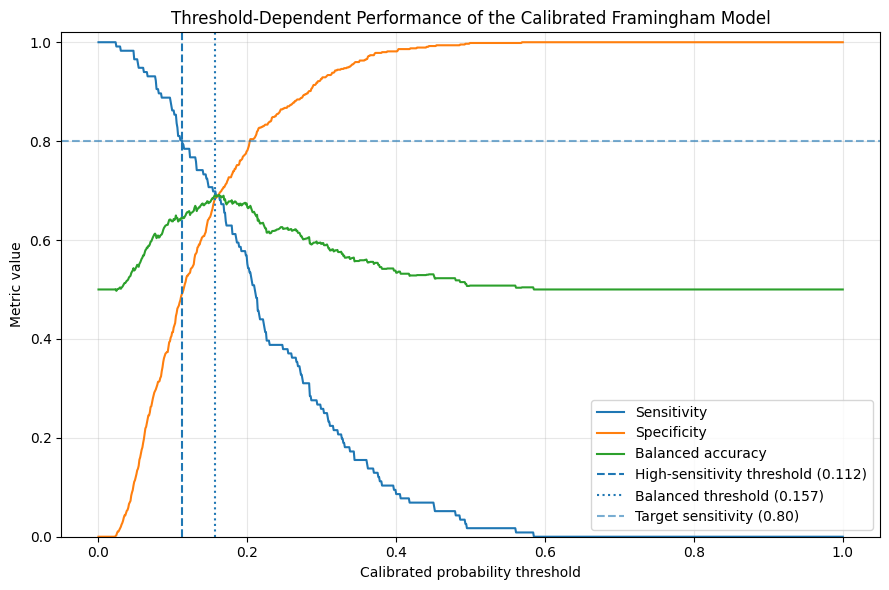

In [90]:
# Plot calibrated threshold behavior

plt.figure(figsize=(9, 6))

plt.plot(
    calibrated_threshold_results["threshold"],
    calibrated_threshold_results["sensitivity"],
    label="Sensitivity",
)

plt.plot(
    calibrated_threshold_results["threshold"],
    calibrated_threshold_results["specificity"],
    label="Specificity",
)

plt.plot(
    calibrated_threshold_results["threshold"],
    calibrated_threshold_results[
        "balanced_accuracy"
    ],
    label="Balanced accuracy",
)

plt.axvline(
    calibrated_high_sensitivity_threshold,
    linestyle="--",
    label=(
        "High-sensitivity threshold "
        f"({calibrated_high_sensitivity_threshold:.3f})"
    ),
)

plt.axvline(
    calibrated_balanced_threshold,
    linestyle=":",
    label=(
        "Balanced threshold "
        f"({calibrated_balanced_threshold:.3f})"
    ),
)

plt.axhline(
    TARGET_SENSITIVITY,
    linestyle="--",
    alpha=0.6,
    label=(
        f"Target sensitivity "
        f"({TARGET_SENSITIVITY:.2f})"
    ),
)

plt.xlabel("Calibrated probability threshold")
plt.ylabel("Metric value")
plt.title(
    "Threshold-Dependent Performance of the "
    "Calibrated Framingham Model"
)
plt.ylim(0, 1.02)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()

plt.savefig(
    "framingham_plots/"
    "calibrated_model_threshold_selection.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

### Probability Calibration

Sigmoid calibration substantially improved probability accuracy while preserving the
discriminative performance of the selected logistic regression model. The previously
observed reduction in recall resulted from applying the same numerical thresholds before
and after calibration, despite the change in probability scale.

Operating thresholds were therefore selected directly from calibrated probabilities on
the dedicated validation split. A high-sensitivity threshold of 0.112 was selected as
the highest threshold achieving sensitivity of at least 0.80, yielding sensitivity of
0.802 and specificity of 0.491 on the validation data. A secondary balanced threshold
of 0.157 maximized balanced accuracy, yielding sensitivity of 0.698 and specificity of
0.685.

The sigmoid-calibrated logistic regression model was selected as the final Framingham
probability model because it provides better-calibrated risk estimates while preserving
the desired sensitivity-oriented operating behavior after threshold adjustment. The
high-sensitivity threshold of 0.112 was retained as the primary operating threshold for
screening-oriented evaluation, while the balanced threshold of 0.157 was retained as a
secondary operating scenario for referral prioritization. Both thresholds were fixed
before evaluation on the final holdout set.

## Holdout Test Set

In [91]:
# Final sigmoid-calibrated logistic regression model

final_calibrated_logreg = CalibratedClassifierCV(
    estimator=Pipeline([
        ("preprocess", preprocessor),
        ("model", LogisticRegression(
            C=0.1,
            class_weight="balanced",
            max_iter=3000,
            random_state=42,
        )),
    ]),
    method="sigmoid",
    cv=5,
)

# Refit on the complete development set only
final_calibrated_logreg.fit(
    X_dev,
    y_dev,
)

# Generate probabilities on the untouched final holdout
y_proba_test_calibrated = (
    final_calibrated_logreg
    .predict_proba(X_test_final)[:, 1]
)

# Thresholds selected previously on the dedicated validation split
FINAL_HIGH_SENSITIVITY_THRESHOLD = (
    calibrated_high_sensitivity_threshold
)

FINAL_BALANCED_THRESHOLD = (
    calibrated_balanced_threshold
)

print(
    "Final high-sensitivity threshold:",
    f"{FINAL_HIGH_SENSITIVITY_THRESHOLD:.3f}",
)

print(
    "Final balanced threshold:",
    f"{FINAL_BALANCED_THRESHOLD:.3f}",
)

Final high-sensitivity threshold: 0.112
Final balanced threshold: 0.157


In [92]:
# Threshold-independent final holdout metrics

final_roc_auc = roc_auc_score(
    y_test_final,
    y_proba_test_calibrated,
)

final_pr_auc = average_precision_score(
    y_test_final,
    y_proba_test_calibrated,
)

final_brier = brier_score_loss(
    y_test_final,
    y_proba_test_calibrated,
)

print("=== Final Calibrated Holdout Evaluation ===")
print(f"ROC-AUC: {final_roc_auc:.4f}")
print(f"PR-AUC (Average Precision): {final_pr_auc:.4f}")
print(f"Brier Score: {final_brier:.4f}")
print(
    "Positive class prevalence:",
    f"{y_test_final.mean():.4f}",
)

=== Final Calibrated Holdout Evaluation ===
ROC-AUC: 0.7164
PR-AUC (Average Precision): 0.3108
Brier Score: 0.1196
Positive class prevalence: 0.1509


In [93]:
# Evaluate the two fixed operating scenarios

def evaluate_holdout_scenario(
    y_true,
    y_probability,
    threshold,
    scenario_name,
):
    """
    Evaluate one fixed decision threshold on the final holdout set.
    """
    y_true = np.asarray(
        y_true,
        dtype=int,
    )

    y_probability = np.asarray(
        y_probability,
        dtype=float,
    )

    y_predicted = (
        y_probability >= threshold
    ).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_true,
        y_predicted,
        labels=[0, 1],
    ).ravel()

    sensitivity = tp / (tp + fn)
    specificity = tn / (tn + fp)

    precision = (
        tp / (tp + fp)
        if (tp + fp) > 0
        else 0.0
    )

    balanced_accuracy = (
        sensitivity + specificity
    ) / 2

    return {
        "Scenario": scenario_name,
        "Threshold": float(threshold),
        "Sensitivity": sensitivity,
        "Specificity": specificity,
        "Precision": precision,
        "Balanced Accuracy": balanced_accuracy,
        "F1 Score": f1_score(
            y_true,
            y_predicted,
            zero_division=0,
        ),
        "True Positives": int(tp),
        "False Positives": int(fp),
        "True Negatives": int(tn),
        "False Negatives": int(fn),
        "Predicted Positives": int(
            y_predicted.sum()
        ),
    }


final_holdout_scenarios = pd.DataFrame([
    evaluate_holdout_scenario(
        y_true=y_test_final,
        y_probability=y_proba_test_calibrated,
        threshold=FINAL_HIGH_SENSITIVITY_THRESHOLD,
        scenario_name="High-sensitivity triage",
    ),
    evaluate_holdout_scenario(
        y_true=y_test_final,
        y_probability=y_proba_test_calibrated,
        threshold=FINAL_BALANCED_THRESHOLD,
        scenario_name="Balanced referral prioritization",
    ),
])

final_holdout_scenarios.round(4)

,Scenario,Threshold,Sensitivity,Specificity,Precision,Balanced Accuracy,F1 Score,True Positives,False Positives,True Negatives,False Negatives,Predicted Positives
0,High-sensitivity triage,0.112,0.7969,0.5083,0.2237,0.6526,0.3493,51,177,183,13,228
1,Balanced referral prioritization,0.157,0.6250,0.6583,0.2454,0.6417,0.3524,40,123,237,24,163


In [94]:
# Classification reports

for _, scenario in final_holdout_scenarios.iterrows():
    scenario_name = scenario["Scenario"]
    threshold = scenario["Threshold"]

    y_predicted = (
        y_proba_test_calibrated >= threshold
    ).astype(int)

    print(
        f"\n=== {scenario_name} "
        f"(threshold = {threshold:.3f}) ==="
    )

    print(
        classification_report(
            y_test_final,
            y_predicted,
            target_names=[
                "No CHD",
                "CHD",
            ],
            zero_division=0,
        )
    )


=== High-sensitivity triage (threshold = 0.112) ===
              precision    recall  f1-score   support

      No CHD       0.93      0.51      0.66       360
         CHD       0.22      0.80      0.35        64

    accuracy                           0.55       424
   macro avg       0.58      0.65      0.50       424
weighted avg       0.83      0.55      0.61       424


=== Balanced referral prioritization (threshold = 0.157) ===
              precision    recall  f1-score   support

      No CHD       0.91      0.66      0.76       360
         CHD       0.25      0.62      0.35        64

    accuracy                           0.65       424
   macro avg       0.58      0.64      0.56       424
weighted avg       0.81      0.65      0.70       424



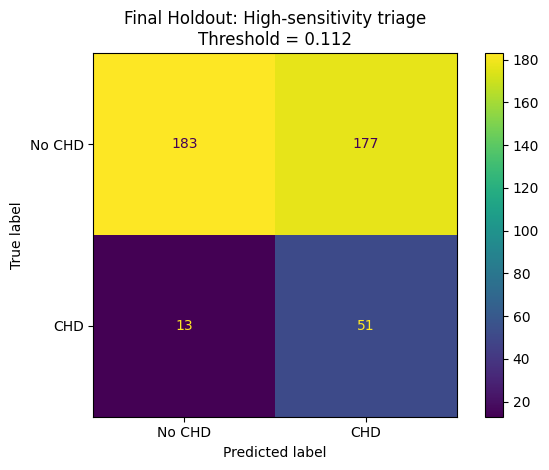

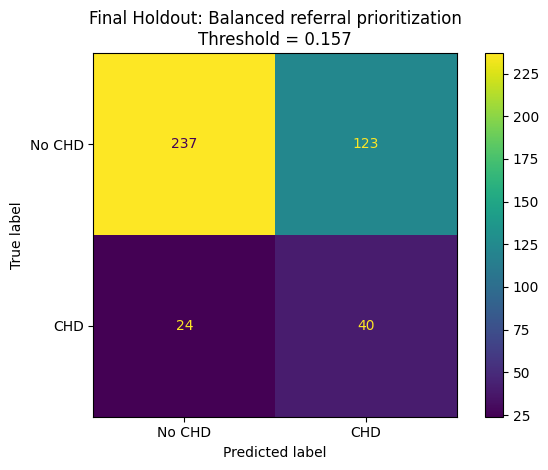

In [95]:
# Confusion matrices

holdout_scenario_thresholds = {
    "High-sensitivity triage": (
        FINAL_HIGH_SENSITIVITY_THRESHOLD
    ),
    "Balanced referral prioritization": (
        FINAL_BALANCED_THRESHOLD
    ),
}

for scenario_name, threshold in (
    holdout_scenario_thresholds.items()
):
    y_predicted = (
        y_proba_test_calibrated >= threshold
    ).astype(int)

    ConfusionMatrixDisplay.from_predictions(
        y_test_final,
        y_predicted,
        labels=[0, 1],
        display_labels=[
            "No CHD",
            "CHD",
        ],
        values_format="d",
    )

    plt.title(
        f"Final Holdout: {scenario_name}\n"
        f"Threshold = {threshold:.3f}"
    )

    plt.tight_layout()

    filename = (
        scenario_name
        .lower()
        .replace("-", "_")
        .replace(" ", "_")
    )

    plt.savefig(
        "framingham_plots/"
        f"final_calibrated_{filename}_confusion_matrix.png",
        dpi=300,
        bbox_inches="tight",
    )

    plt.show()

### Final Model Summary

The sigmoid-calibrated logistic regression model was retained as the final Framingham
model. Calibration substantially improved probability accuracy while preserving the
model's discriminative performance. Because calibration changes the numerical scale of
predicted probabilities, the operating threshold was selected separately using the
dedicated validation split rather than retaining the default threshold of 0.5.

The final operating threshold was selected for a screening-oriented use case in which
false-negative predictions are considered more consequential than false positives. The
highest threshold achieving sensitivity of at least 0.80 was selected, thereby maximizing
specificity subject to the prespecified sensitivity requirement. This procedure yielded a
threshold of 0.112, which was fixed before final holdout evaluation.

On the untouched holdout set, the final model achieved ROC-AUC of 0.716, PR-AUC of
0.311, and Brier score of 0.120. At the fixed threshold of 0.112, sensitivity was 0.797
and specificity was 0.508, closely reproducing the intended operating behavior observed
during threshold selection. The model identified 51 of 64 positive cases while missing
13, at the cost of 177 false-positive classifications.

A single operating threshold was retained because the Framingham component is intended
for sensitivity-oriented risk triage rather than diagnosis or general-purpose
classification. Positive classifications should therefore be interpreted as indications
for further assessment rather than definitive disease predictions. The calibrated model
and fixed threshold of 0.112 were retained for subsequent risk-stratification,
decision-curve, and application analyses.

# Save for future deployment

In [96]:
# Metadata

os.makedirs("artifacts", exist_ok=True)

# Final holdout predictions from the already-fitted final calibrated model
y_proba_test = final_calibrated_logreg.predict_proba(
    X_test_final
)[:, 1]

y_pred_test = (
    y_proba_test >= FINAL_HIGH_SENSITIVITY_THRESHOLD
).astype(int)

metadata = {
    "model_name": "Framingham CHD Risk Model",
    "model_type": "CalibratedClassifierCV",
    "target": "TenYearCHD",
    "final_model_choice": (
        "sigmoid-calibrated logistic regression"
    ),
    "threshold": float(
        FINAL_HIGH_SENSITIVITY_THRESHOLD
    ),

    "hyperparameters": {
        "base_estimator": "LogisticRegression",
        "C": 0.1,
        "max_iter": 3000,
        "class_weight": "balanced",
        "random_state": 42,
        "calibration_method": "sigmoid",
        "calibration_cv": 5,
    },

    "training_data": {
        "development_rows": int(X_dev.shape[0]),
        "holdout_rows": int(X_test_final.shape[0]),
        "feature_count_raw": int(X_dev.shape[1]),
    },

    "preprocessing": {
        "implemented_inside_pipeline": True,
        "missing_indicator_columns": [
            "glucose",
            "education",
            "BPMeds",
        ],
        "clipped_columns": [
            "glucose",
            "totChol",
            "sysBP",
        ],
        "clip_quantiles": {
            "lower": 0.01,
            "upper": 0.99,
        },
        "continuous_features": continuous_cols,
        "binary_or_categorical_features": (
            binary_or_cat_cols
        ),
        "passthrough_features": passthrough_cols,
    },

    "model_selection": {
        "selected_via": (
            "repeated stratified cross-validation "
            "on development set"
        ),
        "chosen_over": [
            "Random Forest",
            "Stacking Ensemble",
        ],
        "calibration": {
            "method": "sigmoid",
            "cv": 5,
            "rationale": (
                "Calibration improved probability accuracy "
                "while preserving discrimination. The "
                "classification threshold was selected "
                "separately on a dedicated validation split "
                "for the intended sensitivity-oriented "
                "screening use case."
            ),
        },
        "threshold_selection": {
            "selection_data": (
                "dedicated validation split from development set"
            ),
            "selection_rule": (
                "highest threshold achieving sensitivity "
                "of at least 0.80"
            ),
            "target_sensitivity": 0.80,
            "selected_threshold": float(
                FINAL_HIGH_SENSITIVITY_THRESHOLD
            ),
            "intended_use": (
                "high-sensitivity CHD risk triage"
            ),
        },
    },

    "holdout_metrics": {
        "roc_auc": float(
            roc_auc_score(
                y_test_final,
                y_proba_test,
            )
        ),
        "pr_auc": float(
            average_precision_score(
                y_test_final,
                y_proba_test,
            )
        ),
        "brier_score": float(
            brier_score_loss(
                y_test_final,
                y_proba_test,
            )
        ),
        "threshold": float(
            FINAL_HIGH_SENSITIVITY_THRESHOLD
        ),
        "sensitivity": float(
            recall_score(
                y_test_final,
                y_pred_test,
                zero_division=0,
            )
        ),
        "specificity": float(
            recall_score(
                y_test_final,
                y_pred_test,
                pos_label=0,
                zero_division=0,
            )
        ),
        "precision": float(
            precision_score(
                y_test_final,
                y_pred_test,
                zero_division=0,
            )
        ),
        "balanced_accuracy": float(
            balanced_accuracy_score(
                y_test_final,
                y_pred_test,
            )
        ),
        "f1_score": float(
            f1_score(
                y_test_final,
                y_pred_test,
                zero_division=0,
            )
        ),
        "positive_class_prevalence": float(
            np.mean(y_test_final)
        ),
        "true_positives": int(
            confusion_matrix(
                y_test_final,
                y_pred_test,
                labels=[0, 1],
            ).ravel()[3]
        ),
        "false_positives": int(
            confusion_matrix(
                y_test_final,
                y_pred_test,
                labels=[0, 1],
            ).ravel()[1]
        ),
        "true_negatives": int(
            confusion_matrix(
                y_test_final,
                y_pred_test,
                labels=[0, 1],
            ).ravel()[0]
        ),
        "false_negatives": int(
            confusion_matrix(
                y_test_final,
                y_pred_test,
                labels=[0, 1],
            ).ravel()[2]
        ),
    },
}

metadata

{'model_name': 'Framingham CHD Risk Model',
 'model_type': 'CalibratedClassifierCV',
 'target': 'TenYearCHD',
 'final_model_choice': 'sigmoid-calibrated logistic regression',
 'threshold': 0.112,
 'hyperparameters': {'base_estimator': 'LogisticRegression',
  'C': 0.1,
  'max_iter': 3000,
  'class_weight': 'balanced',
  'random_state': 42,
  'calibration_method': 'sigmoid',
  'calibration_cv': 5},
 'training_data': {'development_rows': 3816,
  'holdout_rows': 424,
  'feature_count_raw': 15},
 'preprocessing': {'implemented_inside_pipeline': True,
  'missing_indicator_columns': ['glucose', 'education', 'BPMeds'],
  'clipped_columns': ['glucose', 'totChol', 'sysBP'],
  'clip_quantiles': {'lower': 0.01, 'upper': 0.99},
  'continuous_features': ['age',
   'glucose',
   'totChol',
   'cigsPerDay',
   'BMI',
   'heartRate',
   'sysBP',
   'diaBP'],
  'binary_or_categorical_features': ['education', 'BPMeds'],
  'passthrough_features': ['male',
   'currentSmoker',
   'prevalentStroke',
   'prev

In [97]:
METADATA_NAME = "artifacts/framingham_chd_metadata.json"
MODEL_NAME = "artifacts/framingham_chd_pipeline.joblib"

with open(METADATA_NAME, "w") as f:
    json.dump(metadata, f, indent=4)

model_artifact = {
    "pipeline": final_calibrated_logreg,
    "threshold": float(
        FINAL_HIGH_SENSITIVITY_THRESHOLD
    ),
    "metadata": metadata,
}

joblib.dump(
    model_artifact,
    MODEL_NAME,
)

print(f"Saved model to: {MODEL_NAME}")
print(f"Saved metadata to: {METADATA_NAME}")

Saved model to: artifacts/framingham_chd_pipeline.joblib
Saved metadata to: artifacts/framingham_chd_metadata.json


In [98]:
# Verification step

loaded_artifact = joblib.load(
    "artifacts/framingham_chd_pipeline.joblib"
)

loaded_pipeline = loaded_artifact["pipeline"]
loaded_threshold = loaded_artifact["threshold"]
loaded_metadata = loaded_artifact["metadata"]

sample = X_test_final.iloc[:5].copy()

# Predictions from the loaded artifact
sample_proba = loaded_pipeline.predict_proba(
    sample
)[:, 1]

sample_pred = (
    sample_proba >= loaded_threshold
).astype(int)

# Predictions from the in-memory final model
reference_proba = final_calibrated_logreg.predict_proba(
    sample
)[:, 1]

reference_pred = (
    reference_proba
    >= FINAL_HIGH_SENSITIVITY_THRESHOLD
).astype(int)

# Artifact consistency checks
assert np.allclose(
    sample_proba,
    reference_proba,
)

assert np.array_equal(
    sample_pred,
    reference_pred,
)

assert np.isclose(
    loaded_threshold,
    FINAL_HIGH_SENSITIVITY_THRESHOLD,
)

assert np.isclose(
    loaded_metadata["threshold"],
    FINAL_HIGH_SENSITIVITY_THRESHOLD,
)

print("Loaded threshold:", loaded_threshold)
print("Sample probabilities:", sample_proba)
print("Sample predictions:", sample_pred)
print("Loaded model type:", loaded_metadata["model_type"])
print(
    "Artifact verification passed: "
    "loaded model reproduces final model outputs."
)

Loaded threshold: 0.112
Sample probabilities: [0.2508901  0.10466302 0.14622593 0.09157499 0.11034418]
Sample predictions: [1 0 1 0 0]
Loaded model type: CalibratedClassifierCV
Artifact verification passed: loaded model reproduces final model outputs.


# Understanding Model Behavior and Risk Drivers

## Coefficient and Odds Ratio Analysis

To examine the linear relationships learned by the logistic regression model, coefficient and odds-ratio analysis was performed using the selected logistic regression specification before probability calibration, refitted on the complete development set. The final prediction model applies sigmoid calibration to this underlying classifier; however, the calibrated model does not provide a single coefficient vector that can be interpreted directly. The analysis below therefore characterizes the underlying logistic regression model rather than the final calibrated probabilities.

Logistic regression coefficients represent conditional associations between model inputs and the log-odds of the predicted outcome, holding the other included variables constant. Exponentiating a coefficient gives the corresponding odds ratio (OR): values above 1 indicate higher predicted odds of CHD, values below 1 indicate lower predicted odds, and values close to 1 indicate relatively weak associations.

Because continuous features were standardized during preprocessing, their odds ratios correspond to a one-standard-deviation increase in the original variable. Coefficients for binary variables represent changes between the encoded categories. These estimates describe associations learned by the model and should not be interpreted as causal effects or independent clinical risk estimates.

In [99]:
# Load the final saved calibrated model

artifact = joblib.load(
    "artifacts/framingham_chd_pipeline.joblib"
)

final_pipeline = artifact["pipeline"]
final_threshold = artifact["threshold"]

print("Loaded threshold:", final_threshold)
print(
    "Final calibrated model loaded successfully."
)


# Refit the selected logistic regression before calibration
# on the complete development set for coefficient interpretation

interpretable_logreg_pipeline = clone(
    selected_logreg_pipeline
)

interpretable_logreg_pipeline.fit(
    X_dev,
    y_dev,
)

print(
    "Selected pre-calibration logistic regression "
    "refitted successfully."
)

Loaded threshold: 0.112
Final calibrated model loaded successfully.
Selected pre-calibration logistic regression refitted successfully.


In [100]:
# Extract feature names and coefficients from the
# selected pre-calibration logistic regression

feature_names = (
    interpretable_logreg_pipeline
    .named_steps["preprocess"]
    .get_feature_names_out()
)

coefficients = (
    interpretable_logreg_pipeline
    .named_steps["model"]
    .coef_[0]
)

coef_df = pd.DataFrame({
    "feature": feature_names,
    "coefficient": coefficients,
    "odds_ratio": np.exp(coefficients),
    "abs_coefficient": np.abs(coefficients),
})

coef_df = (
    coef_df
    .sort_values(
        "abs_coefficient",
        ascending=False,
    )
    .reset_index(drop=True)
)

coef_df.head(15)

,feature,coefficient,odds_ratio,abs_coefficient
0,continuous__age,0.569209,1.766869,0.569209
1,passthrough__male,0.398954,1.490266,0.398954
2,passthrough__prevalentStroke,0.347682,1.415782,0.347682
3,binary_cat__BPMeds,0.347487,1.415506,0.347487
4,passthrough__diabetes,0.324801,1.383755,0.324801
5,continuous__cigsPerDay,0.291968,1.339060,0.291968
6,continuous__sysBP,0.251177,1.285537,0.251177
7,passthrough__prevalentHyp,0.165747,1.180274,0.165747
8,missing_flags__education_missing,-0.156170,0.855414,0.156170
9,missing_flags__BPMeds_missing,0.106774,1.112682,0.106774


In [101]:
# Clean feature names for interpretation

coef_df["feature_clean"] = (
    coef_df["feature"]
    .str.replace(
        "continuous__",
        "",
        regex=False,
    )
    .str.replace(
        "binary_cat__",
        "",
        regex=False,
    )
    .str.replace(
        "missing_flags__",
        "",
        regex=False,
    )
    .str.replace(
        "passthrough__",
        "",
        regex=False,
    )
)

coef_df_display = coef_df[
    [
        "feature_clean",
        "coefficient",
        "odds_ratio",
        "abs_coefficient",
    ]
].copy()

coef_df_display[
    [
        "coefficient",
        "odds_ratio",
        "abs_coefficient",
    ]
] = (
    coef_df_display[
        [
            "coefficient",
            "odds_ratio",
            "abs_coefficient",
        ]
    ]
    .round(4)
)

coef_df_display.head(15)

,feature_clean,coefficient,odds_ratio,abs_coefficient
0,age,0.5692,1.7669,0.5692
1,male,0.3990,1.4903,0.3990
2,prevalentStroke,0.3477,1.4158,0.3477
3,BPMeds,0.3475,1.4155,0.3475
4,diabetes,0.3248,1.3838,0.3248
5,cigsPerDay,0.2920,1.3391,0.2920
6,sysBP,0.2512,1.2855,0.2512
7,prevalentHyp,0.1657,1.1803,0.1657
8,education_missing,-0.1562,0.8554,0.1562
9,BPMeds_missing,0.1068,1.1127,0.1068


In [102]:
# Show strongest positive and negative effects separately

positive_effects = (
    coef_df
    .sort_values(
        "coefficient",
        ascending=False,
    )
    [
        [
            "feature_clean",
            "coefficient",
            "odds_ratio",
        ]
    ]
    .copy()
)

negative_effects = (
    coef_df
    .sort_values(
        "coefficient",
        ascending=True,
    )
    [
        [
            "feature_clean",
            "coefficient",
            "odds_ratio",
        ]
    ]
    .copy()
)

positive_effects[
    [
        "coefficient",
        "odds_ratio",
    ]
] = (
    positive_effects[
        [
            "coefficient",
            "odds_ratio",
        ]
    ]
    .round(4)
)

negative_effects[
    [
        "coefficient",
        "odds_ratio",
    ]
] = (
    negative_effects[
        [
            "coefficient",
            "odds_ratio",
        ]
    ]
    .round(4)
)

print("Top positive effects:")
display(
    positive_effects.head(10)
)

print("Top negative effects:")
display(
    negative_effects.head(10)
)

Top positive effects:


,feature_clean,coefficient,odds_ratio
0,age,0.5692,1.7669
1,male,0.3990,1.4903
2,prevalentStroke,0.3477,1.4158
3,BPMeds,0.3475,1.4155
4,diabetes,0.3248,1.3838
5,cigsPerDay,0.2920,1.3391
6,sysBP,0.2512,1.2855
7,prevalentHyp,0.1657,1.1803
9,BPMeds_missing,0.1068,1.1127
10,glucose,0.0987,1.1037


Top negative effects:


,feature_clean,coefficient,odds_ratio
8,education_missing,-0.1562,0.8554
14,education,-0.0257,0.9746
17,glucose_missing,0.0006,1.0006
16,heartRate,0.0068,1.0068
15,currentSmoker,0.0095,1.0096
13,diaBP,0.0338,1.0344
12,BMI,0.0373,1.0380
11,totChol,0.0690,1.0715
10,glucose,0.0987,1.1037
9,BPMeds_missing,0.1068,1.1127


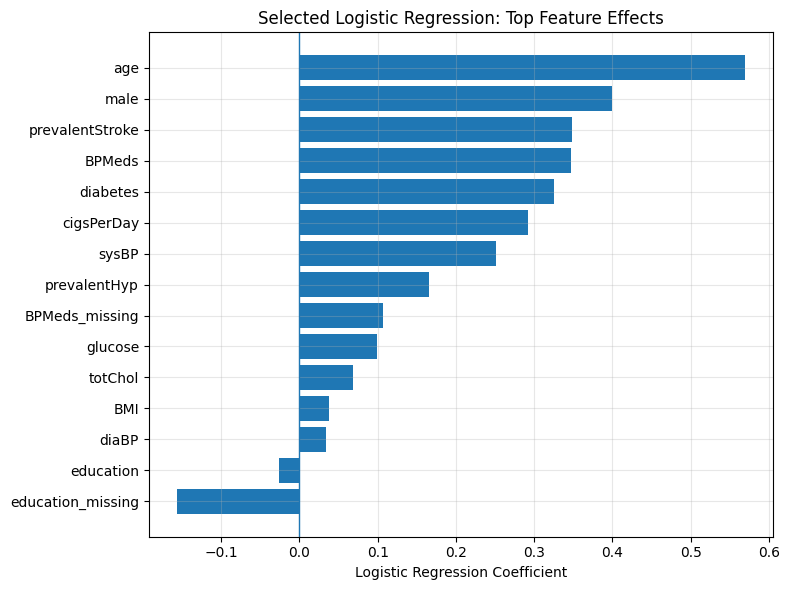

In [103]:
# Coefficient plot

top_n = 15

plot_df = (
    coef_df
    .head(top_n)
    .sort_values("coefficient")
)

plt.figure(
    figsize=(8, 6)
)

plt.barh(
    plot_df["feature_clean"],
    plot_df["coefficient"],
)

plt.axvline(
    0,
    linewidth=1,
)

plt.xlabel(
    "Logistic Regression Coefficient"
)

plt.title(
    "Selected Logistic Regression: "
    "Top Feature Effects"
)

plt.grid(
    True,
    alpha=0.3,
)

plt.tight_layout()

plt.savefig(
    "framingham_plots/"
    "understanding_top_feature_effects.png",
    bbox_inches="tight",
)

plt.show()

In [104]:
# Small helper for plain-language interpretation

def interpret_odds_ratio(
    feature,
    odds_ratio,
):
    if odds_ratio > 1:
        change = (
            odds_ratio - 1
        ) * 100

        return (
            f"A one-unit increase in {feature} is associated "
            f"with about {change:.1f}% higher predicted odds "
            f"of CHD, holding other model inputs constant."
        )

    elif odds_ratio < 1:
        change = (
            1 - odds_ratio
        ) * 100

        return (
            f"A one-unit increase in {feature} is associated "
            f"with about {change:.1f}% lower predicted odds "
            f"of CHD, holding other model inputs constant."
        )

    else:
        return (
            f"{feature} shows little effect on the "
            f"predicted odds of CHD."
        )


for _, row in coef_df.head(5).iterrows():
    print(
        interpret_odds_ratio(
            row["feature_clean"],
            row["odds_ratio"],
        )
    )

A one-unit increase in age is associated with about 76.7% higher predicted odds of CHD, holding other model inputs constant.
A one-unit increase in male is associated with about 49.0% higher predicted odds of CHD, holding other model inputs constant.
A one-unit increase in prevalentStroke is associated with about 41.6% higher predicted odds of CHD, holding other model inputs constant.
A one-unit increase in BPMeds is associated with about 41.6% higher predicted odds of CHD, holding other model inputs constant.
A one-unit increase in diabetes is associated with about 38.4% higher predicted odds of CHD, holding other model inputs constant.


In [105]:
# Feature groups used for interpretation

continuous_feature_set = set(
    continuous_cols
)


def interpret_odds_ratio(
    feature,
    odds_ratio,
):
    if feature in continuous_feature_set:
        change_description = (
            f"a one-standard-deviation increase in {feature}"
        )
    else:
        change_description = (
            f"a one-unit change in {feature}"
        )

    if odds_ratio > 1:
        change = (
            odds_ratio - 1
        ) * 100

        return (
            f"{change_description.capitalize()} is associated "
            f"with about {change:.1f}% higher predicted odds "
            f"of CHD, holding other model inputs constant."
        )

    elif odds_ratio < 1:
        change = (
            1 - odds_ratio
        ) * 100

        return (
            f"{change_description.capitalize()} is associated "
            f"with about {change:.1f}% lower predicted odds "
            f"of CHD, holding other model inputs constant."
        )

    else:
        return (
            f"{feature} shows little effect on the "
            f"predicted odds of CHD."
        )


for _, row in coef_df.head(5).iterrows():
    print(
        interpret_odds_ratio(
            row["feature_clean"],
            row["odds_ratio"],
        )
    )

A one-standard-deviation increase in age is associated with about 76.7% higher predicted odds of CHD, holding other model inputs constant.
A one-unit change in male is associated with about 49.0% higher predicted odds of CHD, holding other model inputs constant.
A one-unit change in prevalentstroke is associated with about 41.6% higher predicted odds of CHD, holding other model inputs constant.
A one-unit change in bpmeds is associated with about 41.6% higher predicted odds of CHD, holding other model inputs constant.
A one-unit change in diabetes is associated with about 38.4% higher predicted odds of CHD, holding other model inputs constant.


### Coefficient and Odds Ratio Analysis Summary

The selected logistic regression assigned its largest positive coefficient to age (OR ≈ 1.77 per one-standard-deviation increase), followed by male sex, prevalent stroke, antihypertensive medication use, diabetes, smoking intensity, and systolic blood pressure. Smoking intensity contributed more strongly than the binary smoking indicator, while several blood-pressure-related variables contributed jointly to prediction.

Most remaining coefficients were comparatively small. Missingness indicators also contributed to prediction, suggesting that missing-data patterns capture dataset-specific information and should not be interpreted as clinical risk factors. Overall, the analysis provides a transparent view of the associations learned by the underlying logistic regression model, while final predictions remain based on the calibrated model and selected high-sensitivity threshold.

## Feature Importance (Standardized Effects and Model Comparison)

In [106]:
# Logistic regression importance

logreg_model = (
    interpretable_logreg_pipeline
    .named_steps["model"]
)

logreg_feature_names = (
    interpretable_logreg_pipeline
    .named_steps["preprocess"]
    .get_feature_names_out()
)

logreg_coefficients = logreg_model.coef_[0]

logreg_importance = pd.DataFrame({
    "feature": logreg_feature_names,
    "importance": np.abs(logreg_coefficients),
    "coefficient": logreg_coefficients,
})

logreg_importance["feature_clean"] = (
    logreg_importance["feature"]
    .str.replace("continuous__", "", regex=False)
    .str.replace("binary_cat__", "", regex=False)
    .str.replace("missing_flags__", "", regex=False)
    .str.replace("passthrough__", "", regex=False)
)

logreg_importance = (
    logreg_importance
    .sort_values(
        "importance",
        ascending=False,
    )
    .reset_index(drop=True)
)

logreg_importance.head(15)

,feature,importance,coefficient,feature_clean
0,continuous__age,0.569209,0.569209,age
1,passthrough__male,0.398954,0.398954,male
2,passthrough__prevalentStroke,0.347682,0.347682,prevalentStroke
3,binary_cat__BPMeds,0.347487,0.347487,BPMeds
4,passthrough__diabetes,0.324801,0.324801,diabetes
5,continuous__cigsPerDay,0.291968,0.291968,cigsPerDay
6,continuous__sysBP,0.251177,0.251177,sysBP
7,passthrough__prevalentHyp,0.165747,0.165747,prevalentHyp
8,missing_flags__education_missing,0.156170,-0.156170,education_missing
9,missing_flags__BPMeds_missing,0.106774,0.106774,BPMeds_missing


In [107]:
# Random forest importance

rf_model = rf_pipeline.named_steps["model"]

rf_feature_names = (
    rf_pipeline
    .named_steps["preprocess"]
    .get_feature_names_out()
)

if not np.array_equal(
    logreg_feature_names,
    rf_feature_names,
):
    raise ValueError(
        "Logistic regression and random forest use different "
        "transformed feature ordering."
    )

rf_importance = pd.DataFrame({
    "feature": rf_feature_names,
    "importance": rf_model.feature_importances_,
})

rf_importance["feature_clean"] = (
    rf_importance["feature"]
    .str.replace("continuous__", "", regex=False)
    .str.replace("binary_cat__", "", regex=False)
    .str.replace("missing_flags__", "", regex=False)
    .str.replace("passthrough__", "", regex=False)
)

rf_importance = (
    rf_importance
    .sort_values(
        "importance",
        ascending=False,
    )
    .reset_index(drop=True)
)

rf_importance.head(15)

,feature,importance,feature_clean
0,continuous__age,0.341457,age
1,continuous__sysBP,0.192504,sysBP
2,continuous__diaBP,0.099794,diaBP
3,passthrough__prevalentHyp,0.069386,prevalentHyp
4,continuous__totChol,0.055665,totChol
5,continuous__cigsPerDay,0.045994,cigsPerDay
6,continuous__glucose,0.042819,glucose
7,continuous__BMI,0.040061,BMI
8,passthrough__male,0.037918,male
9,continuous__heartRate,0.033113,heartRate


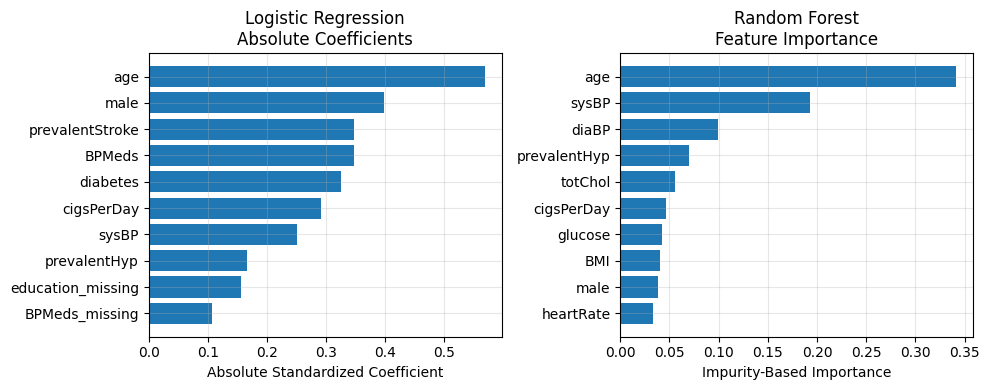

In [108]:
# Visualization

top_n = 10

lr_top = (
    logreg_importance
    .head(top_n)
    .sort_values("importance")
)

rf_top = (
    rf_importance
    .head(top_n)
    .sort_values("importance")
)

fig, axes = plt.subplots(
    1,
    2,
    figsize=(10, 4),
)

# Logistic regression
axes[0].barh(
    lr_top["feature_clean"],
    lr_top["importance"],
)

axes[0].set_title(
    "Logistic Regression\nAbsolute Coefficients"
)

axes[0].set_xlabel(
    "Absolute Standardized Coefficient"
)

axes[0].grid(
    True,
    alpha=0.3,
)

# Random forest
axes[1].barh(
    rf_top["feature_clean"],
    rf_top["importance"],
)

axes[1].set_title(
    "Random Forest\nFeature Importance"
)

axes[1].set_xlabel(
    "Impurity-Based Importance"
)

axes[1].grid(
    True,
    alpha=0.3,
)

plt.tight_layout()

plt.savefig(
    "framingham_plots/"
    "understanding_feature_importance.png",
    bbox_inches="tight",
)

plt.show()

In [109]:
# Combined comparison table

comparison_df = pd.merge(
    logreg_importance[
        [
            "feature_clean",
            "importance",
        ]
    ].rename(
        columns={
            "importance": "lr_importance",
        }
    ),
    rf_importance[
        [
            "feature_clean",
            "importance",
        ]
    ].rename(
        columns={
            "importance": "rf_importance",
        }
    ),
    on="feature_clean",
    how="outer",
)

comparison_df["lr_rank"] = (
    comparison_df["lr_importance"]
    .rank(
        ascending=False,
        method="min",
    )
)

comparison_df["rf_rank"] = (
    comparison_df["rf_importance"]
    .rank(
        ascending=False,
        method="min",
    )
)

comparison_df["rank_difference"] = (
    comparison_df["lr_rank"]
    - comparison_df["rf_rank"]
).abs()

comparison_df = (
    comparison_df
    .sort_values("lr_rank")
    .reset_index(drop=True)
)

comparison_df.head(15).round(4)

,feature_clean,lr_importance,rf_importance,lr_rank,rf_rank,rank_difference
0,age,0.5692,0.3415,1.0,1.0,0.0
1,male,0.3990,0.0379,2.0,9.0,7.0
2,prevalentStroke,0.3477,0.0000,3.0,17.0,14.0
3,BPMeds,0.3475,0.0029,4.0,15.0,11.0
4,diabetes,0.3248,0.0050,5.0,13.0,8.0
5,cigsPerDay,0.2920,0.0460,6.0,6.0,0.0
6,sysBP,0.2512,0.1925,7.0,2.0,5.0
7,prevalentHyp,0.1657,0.0694,8.0,4.0,4.0
8,education_missing,0.1562,0.0001,9.0,16.0,7.0
9,BPMeds_missing,0.1068,0.0000,10.0,17.0,7.0


In [110]:
# Spearman rank correlation between model importance rankings

rank_correlation, rank_correlation_pvalue = spearmanr(
    comparison_df["lr_rank"],
    comparison_df["rf_rank"],
)

print(
    "Spearman rank correlation:",
    f"{rank_correlation:.3f}",
)

print(
    "p-value:",
    f"{rank_correlation_pvalue:.4f}",
)

Spearman rank correlation: 0.072
p-value: 0.7756


### Feature Importance Summary

Both models ranked age as the most important predictor, but their remaining rankings differed substantially. Logistic regression placed greater emphasis on male sex, stroke history, antihypertensive medication use, diabetes, and smoking intensity, whereas random forest relied more heavily on systolic and diastolic blood pressure and other continuous variables. The feature rankings showed little agreement (Spearman ρ = 0.072, p = 0.776), demonstrating that importance estimates are strongly model-dependent.

## Risk Stratification and Clinical Utility

Traditional discrimination metrics such as ROC-AUC and PR-AUC do not directly show whether predicted probabilities meaningfully separate patients by risk or provide value for decision-making. In this section, we therefore evaluate the final calibrated model from two complementary perspectives.

First, we assess risk stratification by grouping patients according to their calibrated predicted probabilities and comparing mean predicted risk with observed CHD event rates. This evaluates whether the model separates lower- and higher-risk individuals and whether predicted risks correspond to observed outcomes.

Next, we use decision-curve analysis to evaluate the net benefit of model-guided decisions relative to treat-all and treat-none strategies, with particular attention to the selected high-sensitivity operating threshold of 0.112.

Together, these analyses examine whether the final calibrated model provides meaningful risk stratification and potential decision-support value beyond its aggregate predictive performance.

In [111]:
# Calibrated probabilities from the final saved model

y_proba_test = final_pipeline.predict_proba(
    X_test_final
)[:, 1]

selected_threshold = float(final_threshold)

# Optional consistency check against the earlier holdout section
if "y_proba_test_calibrated" in globals():
    assert np.allclose(
        y_proba_test,
        y_proba_test_calibrated,
    )

risk_df = pd.DataFrame({
    "y_true": np.asarray(y_test_final, dtype=int),
    "predicted_risk": y_proba_test,
})

# Ranking avoids problems if several patients have identical probabilities
risk_rank = risk_df["predicted_risk"].rank(
    method="first"
)

risk_df["decile"] = pd.qcut(
    risk_rank,
    q=10,
    labels=[
        f"D{i}"
        for i in range(1, 11)
    ],
)

risk_df["quintile"] = pd.qcut(
    risk_rank,
    q=5,
    labels=[
        f"Q{i}"
        for i in range(1, 6)
    ],
)

risk_df.head()

,y_true,predicted_risk,decile,quintile
0,1,0.250890,D9,Q5
1,0,0.104663,D5,Q3
2,0,0.146226,D6,Q3
3,0,0.091575,D4,Q2
4,1,0.110344,D5,Q3


In [112]:
# Decile risk-stratification table

decile_table = (
    risk_df
    .groupby(
        "decile",
        observed=False,
    )
    .agg(
        n_patients=("y_true", "size"),
        mean_predicted_risk=(
            "predicted_risk",
            "mean",
        ),
        observed_event_rate=(
            "y_true",
            "mean",
        ),
        events=("y_true", "sum"),
    )
    .reset_index()
)

decile_table[
    [
        "mean_predicted_risk",
        "observed_event_rate",
    ]
] = decile_table[
    [
        "mean_predicted_risk",
        "observed_event_rate",
    ]
].round(4)

decile_table

,decile,n_patients,mean_predicted_risk,observed_event_rate,events
0,D1,43,0.0340,0.0000,0
1,D2,42,0.0531,0.0238,1
2,D3,42,0.0702,0.0476,2
3,D4,43,0.0897,0.0930,4
4,D5,42,0.1091,0.2381,10
5,D6,42,0.1350,0.0952,4
6,D7,43,0.1669,0.2093,9
7,D8,42,0.2048,0.1905,8
8,D9,42,0.2687,0.2857,12
9,D10,43,0.3873,0.3256,14


In [113]:
# Quintile risk-stratification table

quintile_table = (
    risk_df
    .groupby(
        "quintile",
        observed=False,
    )
    .agg(
        n_patients=("y_true", "size"),
        mean_predicted_risk=(
            "predicted_risk",
            "mean",
        ),
        observed_event_rate=(
            "y_true",
            "mean",
        ),
        events=("y_true", "sum"),
    )
    .reset_index()
)

quintile_table[
    [
        "mean_predicted_risk",
        "observed_event_rate",
    ]
] = quintile_table[
    [
        "mean_predicted_risk",
        "observed_event_rate",
    ]
].round(4)

quintile_table

,quintile,n_patients,mean_predicted_risk,observed_event_rate,events
0,Q1,85,0.0434,0.0118,1
1,Q2,85,0.0801,0.0706,6
2,Q3,84,0.1220,0.1667,14
3,Q4,85,0.1856,0.2000,17
4,Q5,85,0.3287,0.3059,26


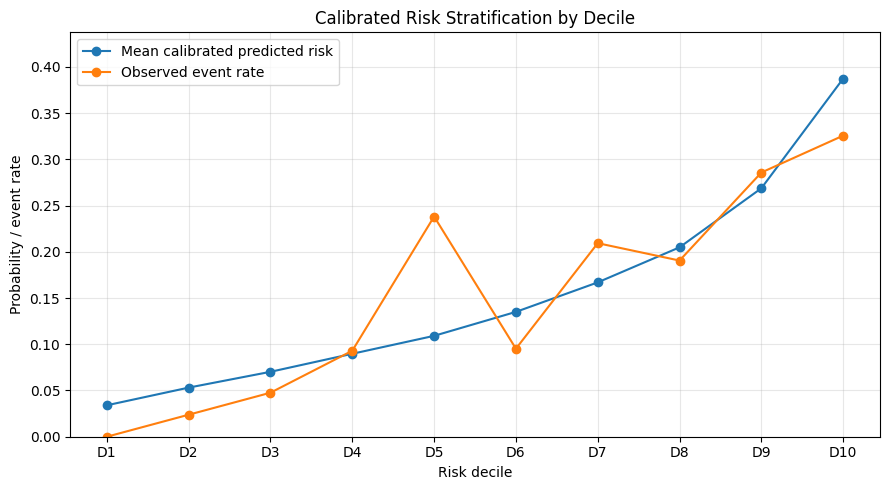

In [114]:
# Predicted versus observed risk by decile

plt.figure(figsize=(9, 5))

plt.plot(
    decile_table["decile"].astype(str),
    decile_table["mean_predicted_risk"],
    marker="o",
    label="Mean calibrated predicted risk",
)

plt.plot(
    decile_table["decile"].astype(str),
    decile_table["observed_event_rate"],
    marker="o",
    label="Observed event rate",
)

plt.xlabel("Risk decile")
plt.ylabel("Probability / event rate")
plt.title(
    "Calibrated Risk Stratification by Decile"
)
plt.ylim(
    0,
    max(
        decile_table[
            [
                "mean_predicted_risk",
                "observed_event_rate",
            ]
        ].to_numpy().max() + 0.05,
        0.35,
    ),
)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()

plt.savefig(
    "framingham_plots/"
    "understanding_risk_stratification.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

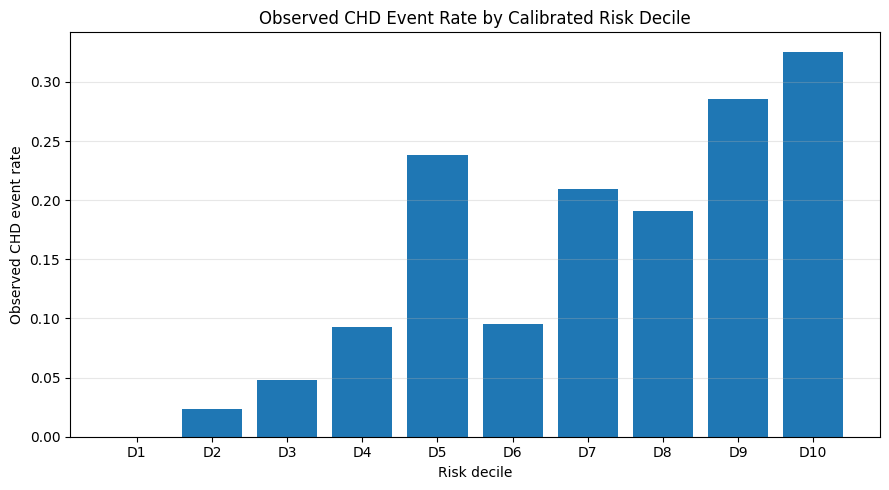

In [115]:
# Observed event rate by calibrated risk decile

plt.figure(figsize=(9, 5))

plt.bar(
    decile_table["decile"].astype(str),
    decile_table["observed_event_rate"],
)

plt.xlabel("Risk decile")
plt.ylabel("Observed CHD event rate")
plt.title(
    "Observed CHD Event Rate by Calibrated Risk Decile"
)
plt.grid(
    axis="y",
    alpha=0.3,
)
plt.tight_layout()

plt.savefig(
    "framingham_plots/"
    "understanding_observed_event_rate_by_risk_decile.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

### Decision Curve Analysis

While risk stratification shows that the model can separate patients into meaningful risk groups, it does not directly answer whether using these predictions would lead to better decisions.

Decision Curve Analysis (DCA) evaluates the **clinical usefulness** of a model by estimating the *net benefit* across a range of decision thresholds. It compares the model against two simple strategies:

* **Treat all patients**
* **Treat no patients**

A model is considered useful if it provides a higher net benefit than these baseline strategies within a relevant range of thresholds.

In [116]:
# Decision curve analysis for the final calibrated model

def compute_net_benefit(
    y_true,
    y_probability,
    thresholds,
):
    """
    Calculate model net benefit across probability thresholds.
    """
    y_true = np.asarray(
        y_true,
        dtype=int,
    )

    y_probability = np.asarray(
        y_probability,
        dtype=float,
    )

    n = len(y_true)
    net_benefits = []

    for threshold in thresholds:
        y_predicted = (
            y_probability >= threshold
        ).astype(int)

        true_positives = int(
            (
                (y_predicted == 1)
                & (y_true == 1)
            ).sum()
        )

        false_positives = int(
            (
                (y_predicted == 1)
                & (y_true == 0)
            ).sum()
        )

        net_benefit = (
            true_positives / n
            - false_positives / n
            * threshold / (1 - threshold)
        )

        net_benefits.append(net_benefit)

    return np.asarray(net_benefits)


# Calibrated probabilities generated earlier in this section
decision_thresholds = np.linspace(
    0.01,
    0.50,
    200,
)

model_net_benefit = compute_net_benefit(
    y_true=y_test_final,
    y_probability=y_proba_test,
    thresholds=decision_thresholds,
)

prevalence = float(
    np.mean(y_test_final)
)

treat_all_net_benefit = np.asarray([
    prevalence
    - (1 - prevalence)
    * threshold / (1 - threshold)
    for threshold in decision_thresholds
])

treat_none_net_benefit = np.zeros_like(
    decision_thresholds
)

selected_threshold = float(
    final_threshold
)

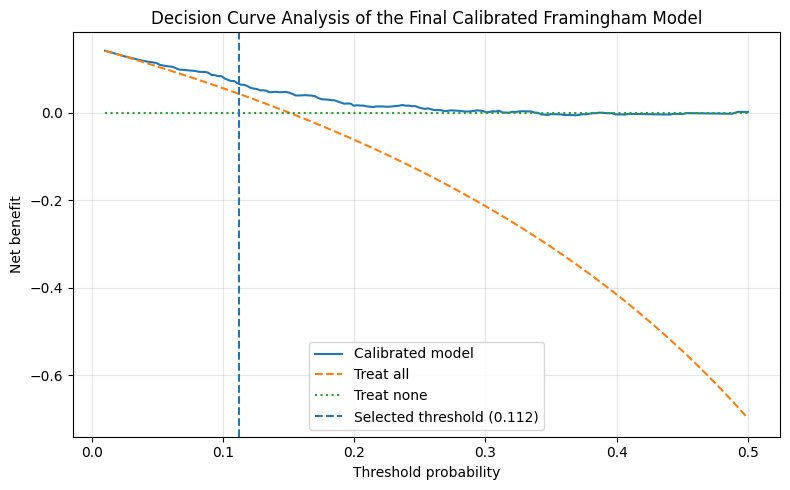

In [117]:
# Decision-curve visualization

plt.figure(figsize=(8, 5))

plt.plot(
    decision_thresholds,
    model_net_benefit,
    label="Calibrated model",
)

plt.plot(
    decision_thresholds,
    treat_all_net_benefit,
    linestyle="--",
    label="Treat all",
)

plt.plot(
    decision_thresholds,
    treat_none_net_benefit,
    linestyle=":",
    label="Treat none",
)

plt.axvline(
    selected_threshold,
    linestyle="--",
    label=(
        "Selected threshold "
        f"({selected_threshold:.3f})"
    ),
)

plt.xlabel("Threshold probability")
plt.ylabel("Net benefit")
plt.title(
    "Decision Curve Analysis of the "
    "Final Calibrated Framingham Model"
)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig(
    "framingham_plots/"
    "understanding_decision_curve.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

In [118]:
# Net benefit at the selected high-sensitivity threshold

selected_model_net_benefit = compute_net_benefit(
    y_true=y_test_final,
    y_probability=y_proba_test,
    thresholds=[selected_threshold],
)[0]

selected_treat_all_net_benefit = (
    prevalence
    - (1 - prevalence)
    * selected_threshold
    / (1 - selected_threshold)
)

selected_threshold_results = pd.DataFrame([
    {
        "Strategy": "Calibrated model",
        "Threshold": selected_threshold,
        "Net Benefit": selected_model_net_benefit,
    },
    {
        "Strategy": "Treat all",
        "Threshold": selected_threshold,
        "Net Benefit": selected_treat_all_net_benefit,
    },
    {
        "Strategy": "Treat none",
        "Threshold": selected_threshold,
        "Net Benefit": 0.0,
    },
])

selected_threshold_results[
    [
        "Threshold",
        "Net Benefit",
    ]
] = selected_threshold_results[
    [
        "Threshold",
        "Net Benefit",
    ]
].round(4)

selected_threshold_results

,Strategy,Threshold,Net Benefit
0,Calibrated model,0.112,0.0676
1,Treat all,0.112,0.0439
2,Treat none,0.112,0.0000


### Risk Stratification and Clinical Utility - Summary

The final calibrated model demonstrates meaningful risk stratification. Patients assigned to higher predicted-risk groups generally show higher observed CHD event rates, with the clearest pattern in the quintile analysis: observed event rates increase from approximately 1% in the lowest-risk quintile to 31% in the highest-risk quintile. The highest-risk groups also contain a substantial proportion of observed CHD cases, indicating that the model effectively concentrates events among patients assigned higher risk.

The decile analysis shows greater variability, particularly in the middle-risk groups, which is expected given the relatively small number of patients and events within each decile. Nevertheless, the overall progression from low-risk to high-risk groups remains evident. The quintile analysis provides a more stable view of this relationship and shows reasonably close agreement between mean predicted risk and observed event rates.

Decision curve analysis further indicates that the model's risk estimates can support useful decision-making. At the selected high-sensitivity threshold of 0.112, the calibrated model achieves a net benefit of 0.0676, exceeding both the treat-all strategy (0.0439) and the treat-none strategy (0.0000). This supports the use of the selected threshold for triage-oriented screening, where identifying a larger proportion of patients who develop CHD is prioritized while still providing greater clinical utility than either baseline strategy.

Overall, the final calibrated model is useful primarily as a risk-stratification and screening tool. It separates patients into clinically meaningful risk groups and provides positive decision value at the selected operating threshold, supporting its intended use for identifying patients who may benefit from further assessment or preventive intervention.

# Conclusion

This project developed a machine learning model for predicting 10-year risk of coronary heart disease (CHD) using the Framingham dataset. Multiple modeling approaches were explored, including logistic regression, random forest, gradient boosting, and ensemble methods. After systematic model comparison, probability calibration, threshold selection, and evaluation on an untouched holdout set, a calibrated logistic regression model with tailored preprocessing was selected as the final solution. The model provides moderate discrimination, improved probability calibration, meaningful risk stratification, and an operating threshold aligned with the intended high-sensitivity screening objective.

## Key decisions

Several key decisions shaped the final model. Logistic regression provided the most consistent combination of cross-validation performance, stability, and interpretability, while more complex ensemble methods did not demonstrate sufficient improvement to justify their additional complexity.

Probability calibration was subsequently applied to improve the reliability of predicted risks. Rather than using the conventional classification threshold of 0.5, threshold selection was treated as a separate decision problem. A high-sensitivity threshold of **0.112** was selected on the development data to prioritize detection of patients who develop CHD. On the untouched holdout set, this threshold retained approximately **80% sensitivity**, confirming that the selected operating point generalized well to unseen data.

A more balanced threshold was also evaluated but was not retained for final deployment. Although it reduced false positives and improved specificity, it missed substantially more CHD cases and did not align as well with the intended screening and triage use case. The calibrated model with the high-sensitivity threshold was therefore selected as the final model.

## Risk stratification

From a practical perspective, the final model demonstrates meaningful risk stratification capability. Patients assigned to higher predicted-risk groups generally show higher observed CHD event rates, with the clearest separation observed in the quintile analysis. The lowest-risk groups contain very few events, while the highest-risk groups concentrate a substantially larger proportion of CHD cases.

Decision Curve Analysis further supports the practical utility of the selected operating point. At the final threshold of **0.112**, the calibrated model achieves greater net benefit than both the treat-all and treat-none strategies. This indicates that the model can support more useful risk-based decisions than either referring all patients or ignoring model predictions altogether.

Together, these findings support the use of the final model primarily as a **risk stratification and high-sensitivity screening tool**, rather than as a definitive diagnostic system.

## Domain knowledge interpretation

The model's learned relationships are broadly consistent with established cardiovascular risk factors, indicating that it captures meaningful clinical signal. Analysis of the selected logistic regression model identifies age, male sex, prior stroke, blood-pressure-related variables, diabetes, and smoking intensity among the strongest positive predictors of CHD risk.

The results also reveal several more nuanced patterns. Smoking intensity (`cigsPerDay`) carries substantially more predictive signal than binary smoking status, suggesting that exposure intensity is more informative than smoking status alone within this dataset. Missingness indicators also contribute to the model, demonstrating that patterns of missing data can contain predictive information.

Not all observed effects should be interpreted as causal. In particular, missingness indicators such as `education_missing` likely capture dataset-specific patterns or latent subgroups rather than genuine protective effects. More generally, logistic regression coefficients describe conditional associations within the fitted model and should be interpreted cautiously in the presence of correlated predictors and observational data.

## Comparison

When compared with established clinical risk models such as the Framingham Risk Score and SCORE, which typically achieve ROC-AUC values in the range of approximately **0.72 to 0.82** depending on the prediction task and study population, the model developed in this project achieves a holdout ROC-AUC of approximately **0.72**.

While this places the model at the lower end of the reported range, its performance remains broadly consistent with baseline clinical prediction performance, particularly given the relatively small and simplified dataset used. In addition, the model's major predictors align with established cardiovascular risk factors, and the final calibrated model provides useful risk stratification and positive decision value at the selected operating threshold.

## Limitations

Several limitations should be acknowledged. The dataset is a reduced version of the full Framingham study and therefore contains a limited set of predictors compared with contemporary cardiovascular risk models. The relatively small number of CHD events also introduces uncertainty into performance estimates and contributes to variability in fine-grained risk stratification analyses such as deciles.

Class imbalance and missing data required preprocessing decisions that may affect generalization. Although probability calibration improved the reliability of predicted risks overall, agreement between predicted and observed event rates remains imperfect within individual risk groups. The model should therefore not be interpreted as providing exact individual-level risk estimates.

Evaluation was conducted using a single dataset without external validation. Consequently, the model's performance, calibration, selected threshold, and clinical utility may not generalize to other populations or healthcare settings. Prospective evaluation and external validation would be necessary before considering real-world clinical deployment.

Overall, the final calibrated logistic regression model provides a transparent and practically useful approach to CHD risk prediction. Its primary strength lies in identifying and prioritizing higher-risk individuals while retaining high sensitivity for CHD cases. The combination of moderate discrimination, improved probability calibration, meaningful risk stratification, and positive net benefit at the selected threshold supports its use as a **screening and risk-prioritization tool** within the scope of this project, while the identified limitations emphasize the need for external validation before broader clinical application.